In [1]:
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})

ff_dir = Path('results/benchmark/ff_benchmark')
tree_dir = Path('results/benchmark/tree_benchmark')
mlp_dir = Path('results/benchmark/mlp_benchmark')
dppt_dir = Path('results/transformer')
dppt_hpt_dir = Path('results/transformer-hpt')

## Fama MacBeth

In [2]:
factor_order = ['value', 'momentum', 'profitability', 'investment', 'size']

factor_results = {}
for fname in factor_order:
    factor_results[fname] = {
        'returns_ls_unscaled': np.load(ff_dir / f'{fname}_returns_ls_unscaled.npy'),
        'returns_ls_scaled': np.load(ff_dir / f'{fname}_returns_ls_scaled.npy'),
        'returns_lo_unscaled': np.load(ff_dir / f'{fname}_returns_lo_unscaled.npy'),
        'returns_lo_scaled': np.load(ff_dir / f'{fname}_returns_lo_scaled.npy'),
    }

market_rets = np.load(ff_dir / 'market_returns.npy')

fm_ls_rets = np.load(ff_dir / 'fm_returns_ls_unscaled.npy')
fm_ls_scaled = np.load(ff_dir / 'fm_returns_ls_scaled.npy')
fm_lo_rets = np.load(ff_dir / 'fm_returns_lo_unscaled.npy')
fm_lo_scaled = np.load(ff_dir / 'fm_returns_lo_scaled.npy')

ff_monthly = pd.read_csv(ff_dir / 'ff_per_month_metrics.csv')
ff_monthly['eom'] = pd.to_datetime(ff_monthly['eom'])

mkt_s = ff_monthly[
    (ff_monthly['strategy'] == 'market_value_weighted') &
    (ff_monthly['portfolio'] == 'long_only') &
    (ff_monthly['scaling'] == 'scaled')
].sort_values('eom')
market_scaled = mkt_s['return'].to_numpy()

ff_per_year = pd.read_csv(ff_dir / 'ff_per_year_metrics.csv')
fm_betas = pd.read_csv(ff_dir / 'fm_monthly_betas.csv', index_col=0, parse_dates=True)
ff_summary = pd.read_csv(ff_dir / 'fama_french_summary.csv')

results_dir = Path('plots') / ff_dir.name
results_dir.mkdir(parents=True, exist_ok=True)
print(f'factor portfolios loaded: {len(factor_results)}')
print(f'market returns: {len(market_rets)} months')
print(f'fm returns: {len(fm_ls_rets)} months')
print()
print('fama-french headline summary')
print(ff_summary.to_string(index=False))

factor portfolios loaded: 5
market returns: 60 months
fm returns: 60 months

fama-french headline summary
             strategy  portfolio  scaling  sharpe     se  ann_ret  ann_vol  cum_return  max_dd  n_obs
market_value_weighted  long_only unscaled  0.3160 0.1323     3.67    11.61       16.12   21.43     60
market_value_weighted  long_only   scaled  0.2816 0.1316     3.16    11.24       13.46   24.28     60
                value long_short unscaled  1.0352 0.1600    10.23     9.88       62.48    7.53     60
                value long_short   scaled  0.9697 0.1565     9.25     9.53       54.99   10.69     60
                value  long_only unscaled  0.7477 0.1460    10.36    13.86       59.88   20.05     60
                value  long_only   scaled  0.6663 0.1427     7.27    10.92       39.59   18.50     60
             momentum long_short unscaled -0.0311 0.1291    -0.52    16.68       -9.31   28.47     60
             momentum long_short   scaled  0.1099 0.1295     1.51    13.72    

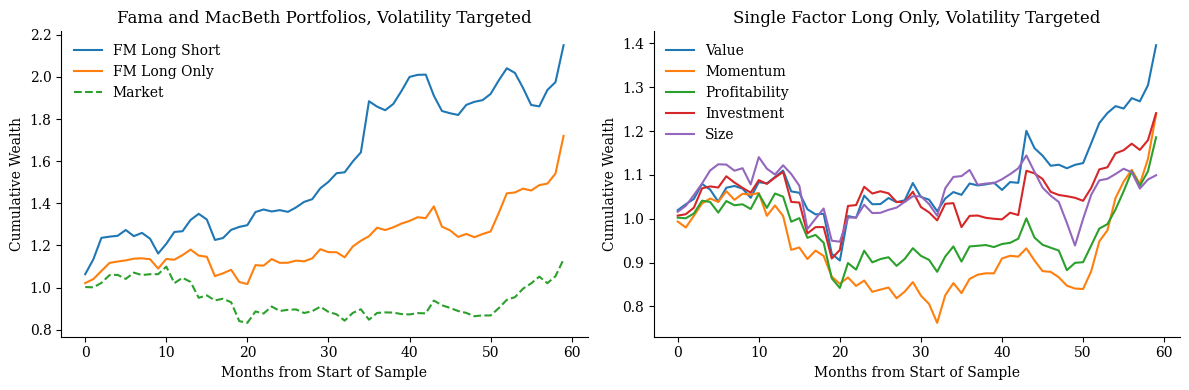

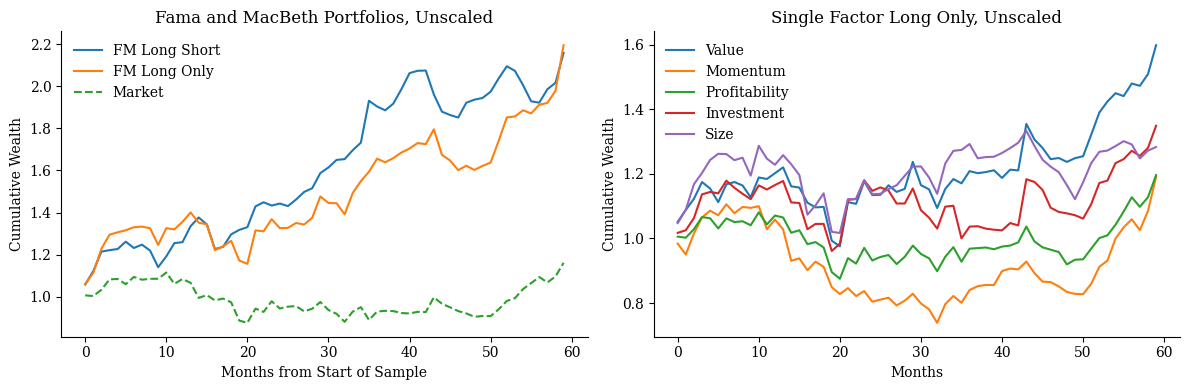

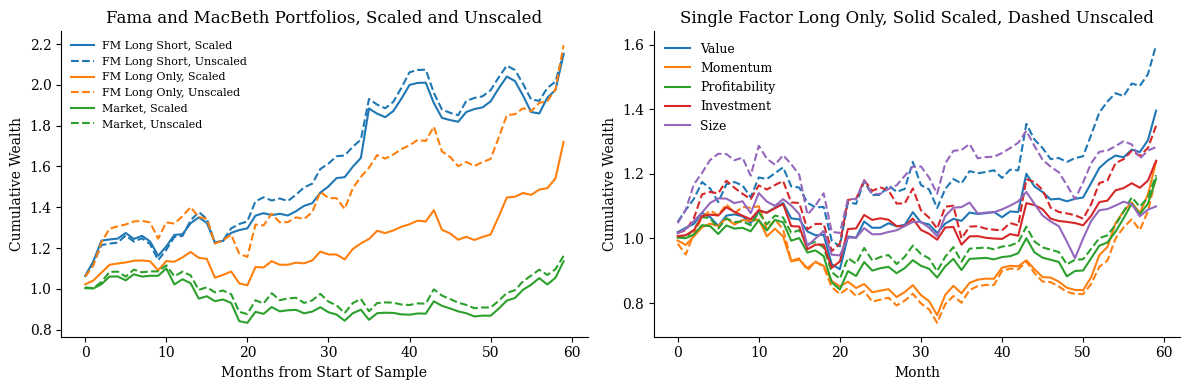

In [3]:
# figure 1, volatility targeted cumulative wealth
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_scaled), label='FM Long Short')
ax.plot(np.cumprod(1 + fm_lo_scaled), label='FM Long Only')
ax.plot(np.cumprod(1 + market_scaled), label='Market', linestyle='--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Volatility Targeted')
ax.legend(frameon=False)

ax = axes[1]
for factor in factor_order:
    if factor in factor_results:
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_scaled']),
            label=factor.title(),
        )
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Volatility Targeted')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_scaled.pdf')
fig.savefig(results_dir / 'ff_cumulative_scaled.png')
plt.show()
plt.close(fig)


# figure 2, unscaled cumulative wealth
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_rets), label='FM Long Short')
ax.plot(np.cumprod(1 + fm_lo_rets), label='FM Long Only')
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label='Market', linestyle='--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Unscaled')
ax.legend(frameon=False)

ax = axes[1]
for factor in factor_order:
    if factor in factor_results:
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']),
            label=factor.title(),
        )
ax.set_xlabel('Months')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Unscaled')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_unscaled.pdf')
fig.savefig(results_dir / 'ff_cumulative_unscaled.png')
plt.show()
plt.close(fig)


# figure 3, scaled and unscaled overlaid, same colour per strategy, solid=scaled dashed=unscaled
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_scaled), label='FM Long Short, Scaled', color='C0')
ax.plot(np.cumprod(1 + fm_ls_rets), label='FM Long Short, Unscaled', color='C0', linestyle='--')
ax.plot(np.cumprod(1 + fm_lo_scaled), label='FM Long Only, Scaled', color='C1')
ax.plot(np.cumprod(1 + fm_lo_rets), label='FM Long Only, Unscaled', color='C1', linestyle='--')
ax.plot(np.cumprod(1 + market_scaled), label='Market, Scaled', color='C2')
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label='Market, Unscaled', color='C2', linestyle='--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Scaled and Unscaled')
ax.legend(frameon=False, fontsize=8, loc='upper left')

ax = axes[1]
for k, factor in enumerate(factor_order):
    if factor in factor_results:
        col = f'C{k}'
        ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_scaled']), label=factor.title(), color=col)
        ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']), color=col, linestyle='--')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Solid Scaled, Dashed Unscaled')
ax.legend(frameon=False, fontsize=9, loc='upper left')

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_combined.pdf')
fig.savefig(results_dir / 'ff_cumulative_combined.png')
plt.show()
plt.close(fig)

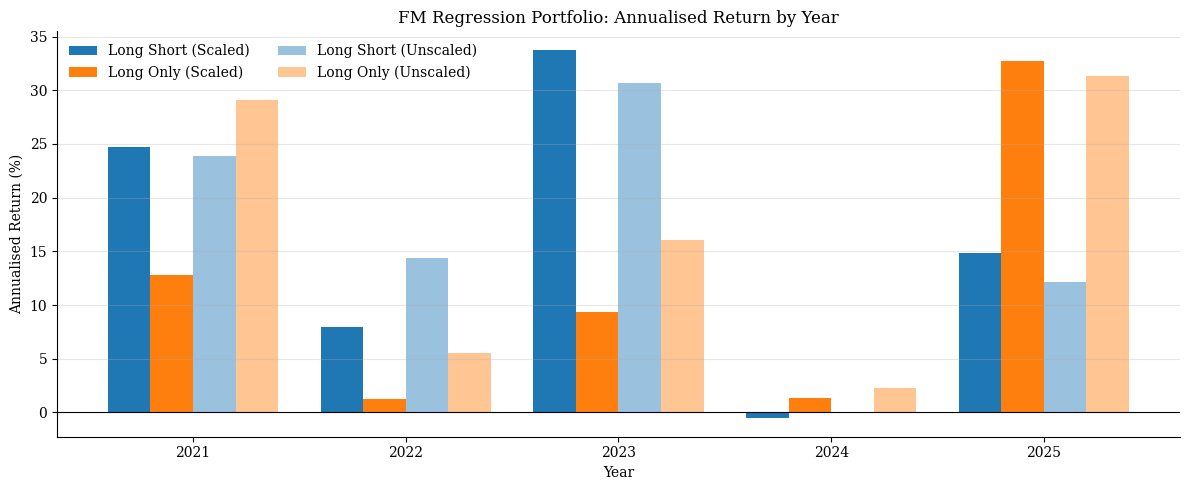

In [4]:
# Separate scaled and unscaled results
fm_scaled = ff_per_year[
    (ff_per_year['strategy'] == 'fm_regression') &
    (ff_per_year['scaling'] == 'scaled')
].copy()

fm_unscaled = ff_per_year[
    (ff_per_year['strategy'] == 'fm_regression') &
    (ff_per_year['scaling'] == 'unscaled')
].copy()

years_ff = sorted(ff_per_year['year'].unique())
x_ff = np.arange(len(years_ff))
width_ff = 0.2


def _ff_val(df, portfolio, year, col):
    sub = df[(df['portfolio'] == portfolio) & (df['year'] == year)]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


# Scaled
ls_scaled = [_ff_val(fm_scaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_scaled = [_ff_val(fm_scaled, 'long_only', y, 'ann_ret') for y in years_ff]

# Unscaled
ls_unscaled = [_ff_val(fm_unscaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_unscaled = [_ff_val(fm_unscaled, 'long_only', y, 'ann_ret') for y in years_ff]

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_ff - 1.5 * width_ff, ls_scaled, width_ff,
       label='Long Short (Scaled)', color='C0')
ax.bar(x_ff - 0.5 * width_ff, lo_scaled, width_ff,
       label='Long Only (Scaled)', color='C1')

ax.bar(x_ff + 0.5 * width_ff, ls_unscaled, width_ff,
       label='Long Short (Unscaled)', color='C0', alpha=0.45)
ax.bar(x_ff + 1.5 * width_ff, lo_unscaled, width_ff,
       label='Long Only (Unscaled)', color='C1', alpha=0.45)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_ff)
ax.set_xticklabels([str(y) for y in years_ff])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('FM Regression Portfolio: Annualised Return by Year')
ax.legend(frameon=False, ncol=2)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_per_year_bar_scaled_unscaled.pdf')
fig.savefig(results_dir / 'ff_per_year_bar_scaled_unscaled.png')
plt.show()
plt.close(fig)

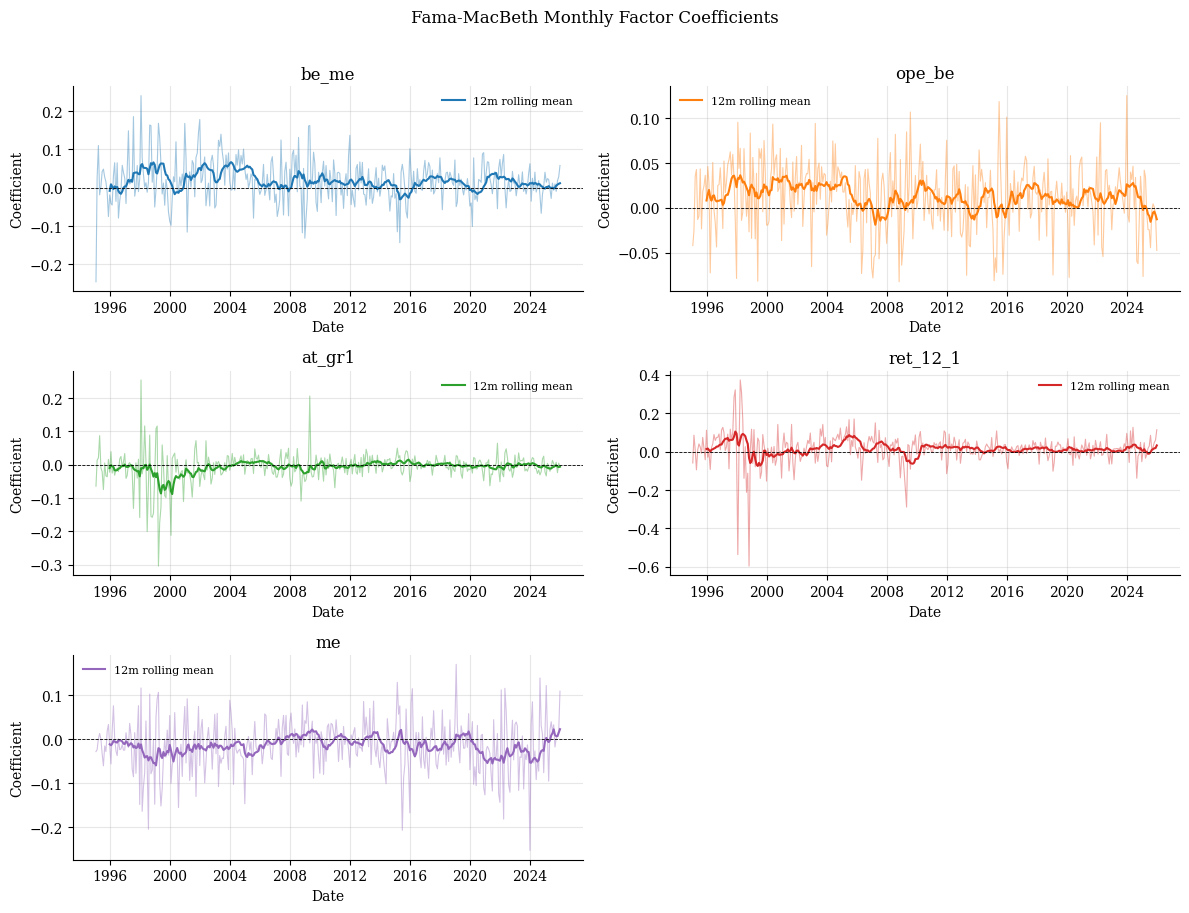

In [5]:
# fama-macbeth factor coefficients over time with 12-month rolling mean
cols_to_plot = [c for c in fm_betas.columns if c != 'intercept']
n_c = len(cols_to_plot)
n_rows_b = (n_c + 1) // 2

fig, axes = plt.subplots(n_rows_b, 2, figsize=(12, n_rows_b * 3))
axes = axes.flatten()

for k, col in enumerate(cols_to_plot):
    ax = axes[k]
    raw = fm_betas[col].dropna()
    roll = raw.rolling(12).mean()
    ax.plot(raw.index.to_numpy(), raw.to_numpy(), alpha=0.4, color=f'C{k}', linewidth=0.8)
    ax.plot(roll.index.to_numpy(), roll.to_numpy(), color=f'C{k}', linewidth=1.5, label='12m rolling mean')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('Date')
    ax.set_ylabel('Coefficient')
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.3)

for k in range(n_c, len(axes)):
    axes[k].set_visible(False)

fig.suptitle('Fama-MacBeth Monthly Factor Coefficients', y=1.01)
fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_beta_stability.pdf')
fig.savefig(results_dir / 'ff_fm_beta_stability.png')
plt.show()
plt.close(fig)

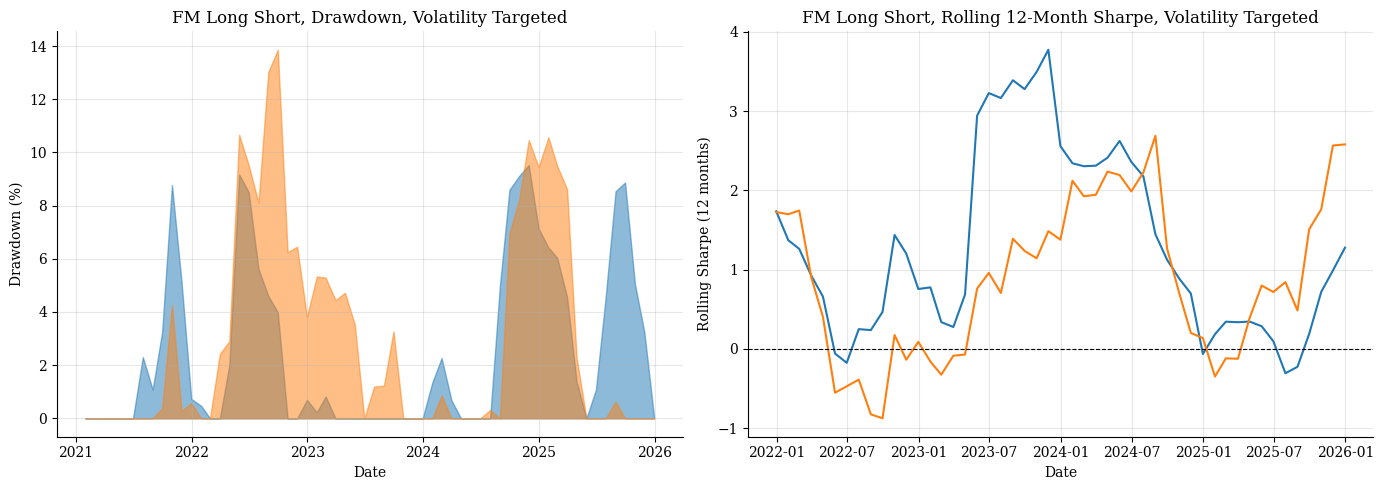

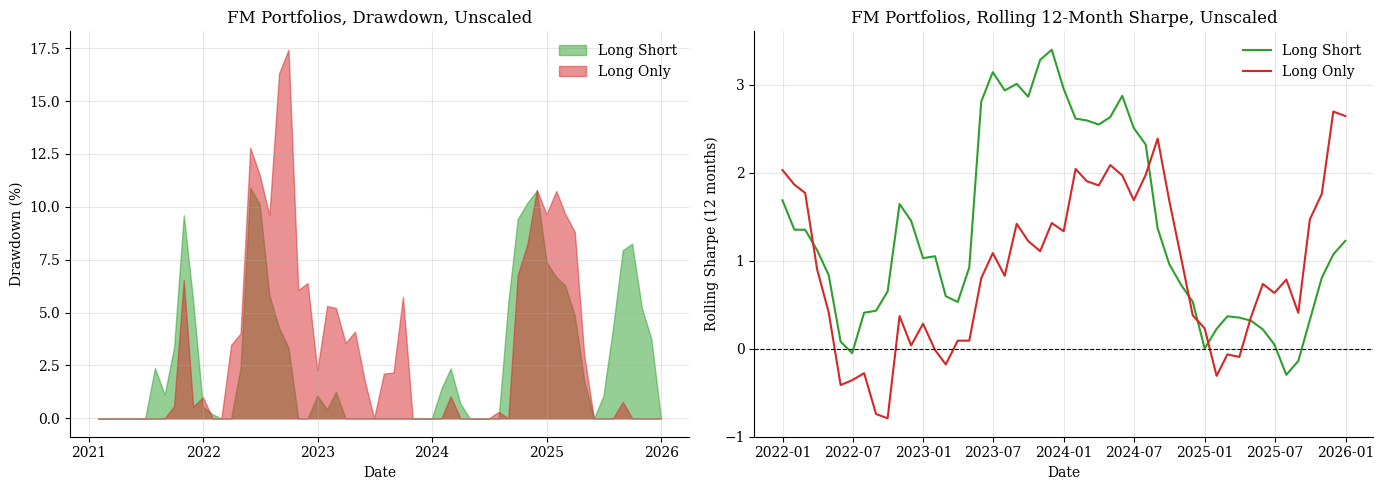

In [6]:
# fm long-short monthly drawdown and rolling 12-month sharpe
fm_ls_mo = ff_monthly[
    (ff_monthly['strategy'] == 'fm_regression') &
    (ff_monthly['portfolio'] == 'long_short') &
    (ff_monthly['scaling'] == 'scaled')
].sort_values('eom')

fm_lo_mo = ff_monthly[
    (ff_monthly['strategy'] == 'fm_regression') &
    (ff_monthly['portfolio'] == 'long_only') &
    (ff_monthly['scaling'] == 'scaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(fm_ls_mo['eom'].to_numpy(), fm_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C0')
ax.fill_between(fm_lo_mo['eom'].to_numpy(), fm_lo_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C1')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Long Short, Drawdown, Volatility Targeted')
ax.grid(alpha=0.3)

ax = axes[1]
valid_s = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_s_lo = fm_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(fm_ls_mo.loc[valid_s, 'eom'].to_numpy(), fm_ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color='C0')
ax.plot(fm_lo_mo.loc[valid_s_lo, 'eom'].to_numpy(), fm_lo_mo.loc[valid_s_lo, 'rolling_sharpe_12m'].to_numpy(), color='C1')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Long Short, Rolling 12-Month Sharpe, Volatility Targeted')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_summary.pdf')
fig.savefig(results_dir / 'ff_fm_rolling_summary.png')
plt.show()
plt.close(fig)

# FM long-short monthly drawdown and rolling 12-month sharpe (Unscaled)

fm_ls_mo = ff_monthly[
    (ff_monthly['strategy'] == 'fm_regression') &
    (ff_monthly['portfolio'] == 'long_short') &
    (ff_monthly['scaling'] == 'unscaled')
].sort_values('eom')

fm_lo_mo = ff_monthly[
    (ff_monthly['strategy'] == 'fm_regression') &
    (ff_monthly['portfolio'] == 'long_only') &
    (ff_monthly['scaling'] == 'unscaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drawdown
ax = axes[0]
ax.fill_between(fm_ls_mo['eom'].to_numpy(), fm_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C2', label='Long Short')
ax.fill_between(fm_lo_mo['eom'].to_numpy(), fm_lo_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C3', label='Long Only')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Portfolios, Drawdown, Unscaled')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# Rolling Sharpe
ax = axes[1]
valid_ls = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = fm_lo_mo['rolling_sharpe_12m'].notna()

ax.plot(fm_ls_mo.loc[valid_ls, 'eom'].to_numpy(), fm_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'].to_numpy(), color='C2', label='Long Short')
ax.plot(fm_lo_mo.loc[valid_lo, 'eom'].to_numpy(),fm_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'].to_numpy(), color='C3',label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Portfolios, Rolling 12-Month Sharpe, Unscaled')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_summary_unscaled.pdf')
fig.savefig(results_dir / 'ff_fm_rolling_summary_unscaled.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

In [7]:
# a firm level prediction file has not been confirmed for the fm
# regression benchmark in the present file set. section 7.2 of the
# benchmark methodology note establishes that the fm regression is the
# only fama french component that produces such a prediction, so the
# read below is attempted against the most plausible file name and
# skipped cleanly, with no plot produced, if the file is absent.
fm_pred_path = ff_dir / 'fm_test_predictions.csv'
try:
	fm_test_pred = pd.read_csv(fm_pred_path)
	fm_test_pred['eom'] = pd.to_datetime(fm_test_pred['eom'])
except FileNotFoundError:
	fm_test_pred = None
	print(f'{fm_pred_path.name} not found, prediction accuracy diagnostic skipped for the fm regression')

if fm_test_pred is not None:
	rows = []
	for eom, group in fm_test_pred.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	fm_monthly_corr = pd.DataFrame(rows).sort_values('eom')

	fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

	def quintile_mean_returns(df):
		def tag(group):
			group = group.copy()
			group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
			return group
		tagged = df.groupby('eom', group_keys = False).apply(tag)
		return tagged.groupby('quintile')['realised_return'].mean()

	fm_quintile_returns = quintile_mean_returns(fm_test_pred)

	ax = axes[0]
	ax.bar(fm_quintile_returns.index.to_numpy(), fm_quintile_returns.to_numpy() * 100, color = 'C0')
	ax.axhline(0, color = 'black', linewidth = 0.6)
	ax.set_xticks(range(1, 6))
	ax.set_xlabel('Predicted Return Quintile')
	ax.set_ylabel('Mean Realised Return (%)')
	ax.set_title('FM Regression, Realised Return by Predicted Quintile')
	ax.grid(alpha = 0.3)

	ax = axes[1]
	ax.plot(fm_monthly_corr['eom'].to_numpy(), fm_monthly_corr['rank_corr'].to_numpy(), color = 'C0', marker = 'o', markersize = 3)
	ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('FM Regression, Monthly Rank Correlation')
	ax.grid(alpha = 0.3)

	fig.tight_layout()
	fig.savefig(results_dir / 'ff_prediction_summary.pdf')
	fig.savefig(results_dir / 'ff_prediction_summary.png')
	plt.show()
	plt.close(fig)


fm_test_predictions.csv not found, prediction accuracy diagnostic skipped for the fm regression


---
## Gradient Boosting Machines

#### Hyperparameter

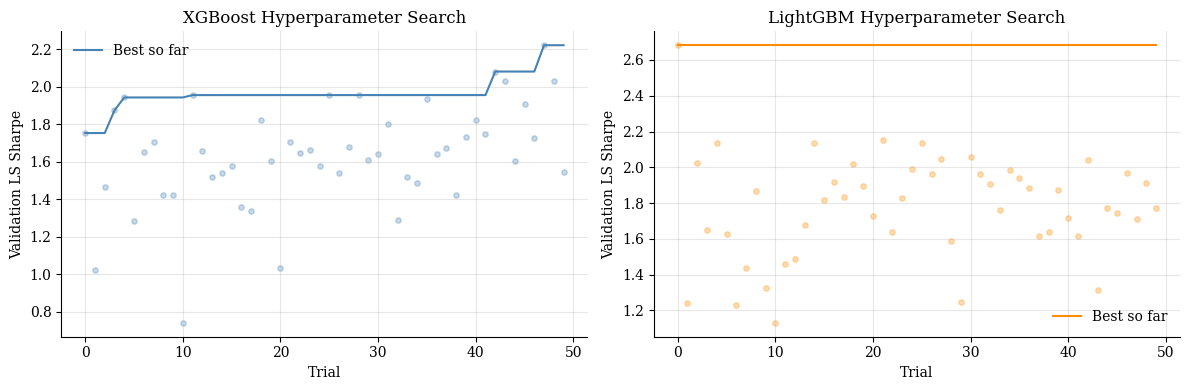

xgboost best val ls sharpe: 2.2217
xgboost best params: {'n_estimators': 598, 'max_depth': 6, 'learning_rate': 0.1308160636442561, 'subsample': 0.9690833187978939, 'colsample_bytree': 0.9957616589543064, 'min_child_weight': 8, 'reg_alpha': 1.459699856402196, 'reg_lambda': 0.30524535962176974}

lightgbm best val ls sharpe: 2.6825
lightgbm best params: {'n_estimators': 580, 'max_depth': 7, 'learning_rate': 0.19992050464904798, 'num_leaves': 39, 'subsample': 0.7444225415856232, 'colsample_bytree': 0.8439045941256622, 'min_child_samples': 30, 'reg_alpha': 0.0030655256872288168, 'reg_lambda': 0.00043814603393441945}


In [8]:
# hpt convergence for xgboost and lightgbm from saved optuna trials csv
tree_plots_dir = Path('plots') / tree_dir.name
tree_plots_dir.mkdir(parents=True, exist_ok=True)

xgb_trials = pd.read_csv(tree_dir / 'xgb_optuna_trials.csv')
lgb_trials = pd.read_csv(tree_dir / 'lgb_optuna_trials.csv')

xgb_color_h = 'steelblue'
lgb_color_h = 'darkorange'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
xgb_vals = xgb_trials['value'].dropna().to_numpy()
ax.plot(np.maximum.accumulate(xgb_vals), color=xgb_color_h, linewidth=1.5, label='Best so far')
ax.scatter(range(len(xgb_vals)), xgb_vals, alpha=0.3, s=15, color=xgb_color_h)
ax.set_xlabel('Trial')
ax.set_ylabel('Validation LS Sharpe')
ax.set_title('XGBoost Hyperparameter Search')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
lgb_vals = lgb_trials['value'].dropna().to_numpy()
ax.plot(np.maximum.accumulate(lgb_vals), color=lgb_color_h, linewidth=1.5, label='Best so far')
ax.scatter(range(len(lgb_vals)), lgb_vals, alpha=0.3, s=15, color=lgb_color_h)
ax.set_xlabel('Trial')
ax.set_ylabel('Validation LS Sharpe')
ax.set_title('LightGBM Hyperparameter Search')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(tree_plots_dir / 'tree_hpt_convergence.pdf')
fig.savefig(tree_plots_dir / 'tree_hpt_convergence.png')
plt.show()
plt.close(fig)

with open(tree_dir / 'xgb_best_params.json') as fh:
    xgb_info = json.load(fh)
with open(tree_dir / 'lgb_best_params.json') as fh:
    lgb_info = json.load(fh)

print(f'xgboost best val ls sharpe: {xgb_info["best_value"]:.4f}')
print(f'xgboost best params: {xgb_info["best_params"]}')
print()
print(f'lightgbm best val ls sharpe: {lgb_info["best_value"]:.4f}')
print(f'lightgbm best params: {lgb_info["best_params"]}')

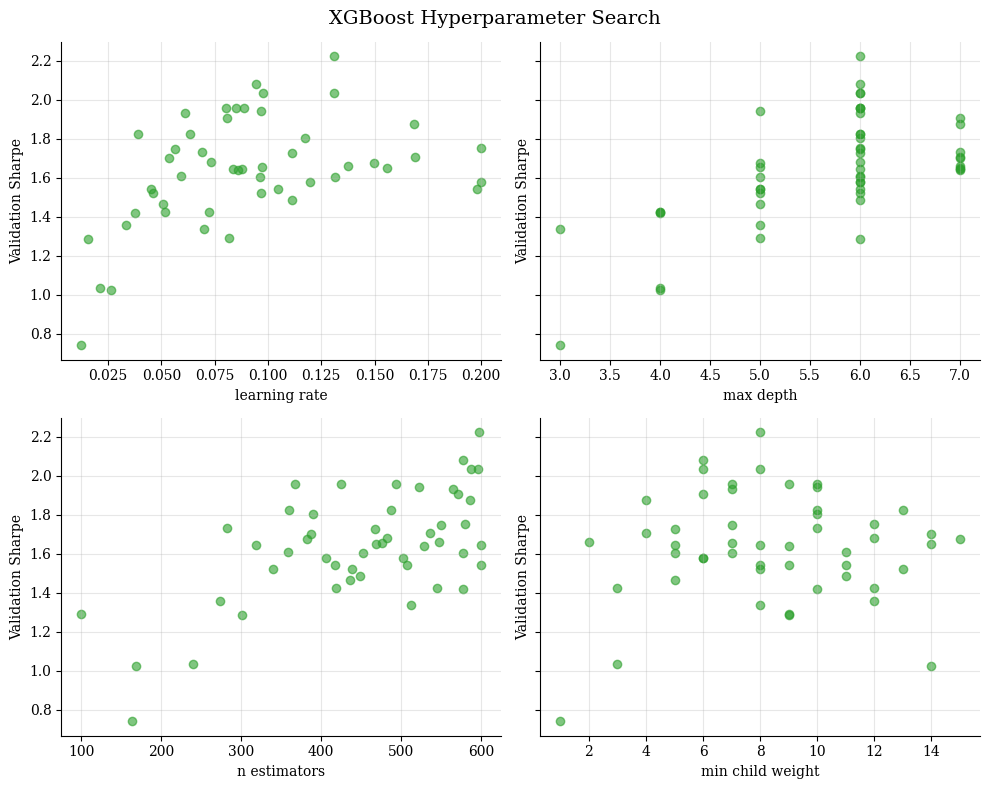

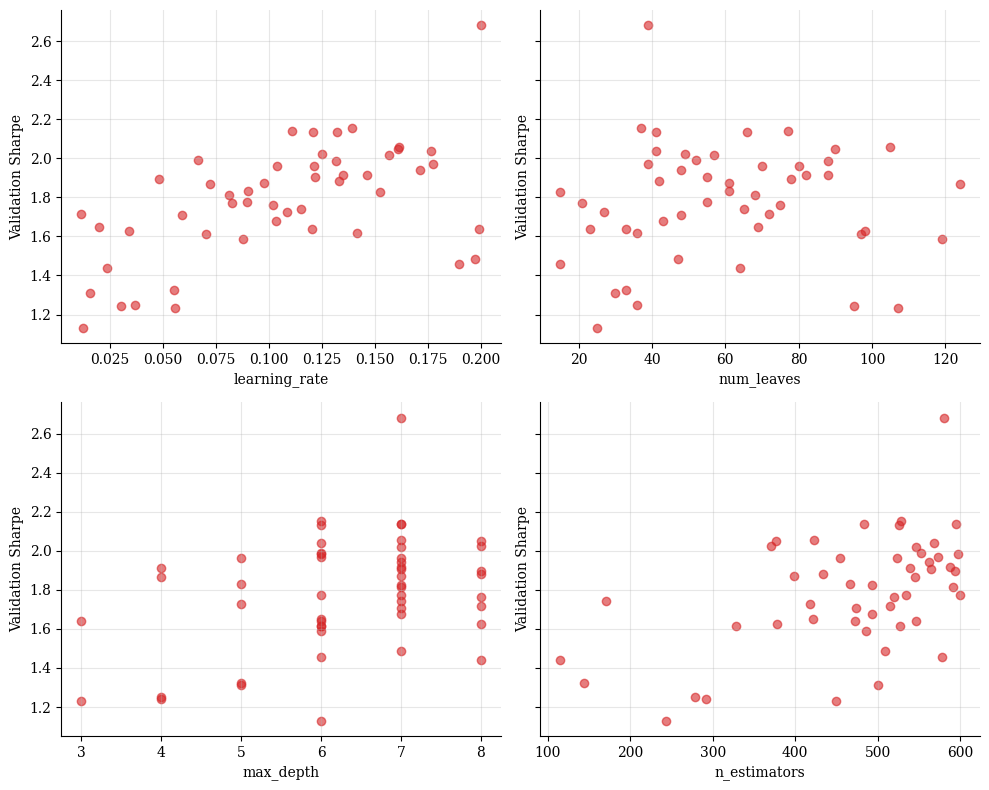

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
params = ['params_learning_rate', 'params_max_depth', 'params_n_estimators','params_min_child_weight']
for ax, p in zip(axes.ravel(), params):
    ax.scatter(xgb_trials[p].to_numpy(), xgb_trials['value'].to_numpy(), alpha=0.6, color='C2')
    ax.set_xlabel(p.replace('params_', '').replace('_', ' '))
    ax.set_ylabel('Validation Sharpe')
    ax.grid(alpha=0.3)

fig.suptitle('XGBoost Hyperparameter Search', fontsize=14)
fig.tight_layout()
fig.savefig(tree_plots_dir / 'xgb_hyperparameter_scatter.pdf')
fig.savefig(tree_plots_dir / 'xgb_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
params = ['params_learning_rate', 'params_num_leaves', 'params_max_depth', 'params_n_estimators']
for ax, p in zip(axes.ravel(), params):
    ax.scatter(lgb_trials[p].to_numpy(), lgb_trials['value'].to_numpy(), alpha=0.6, color='C3')
    ax.set_xlabel(p.replace('params_', ''))
    ax.set_ylabel('Validation Sharpe')
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(tree_plots_dir / 'lgb_hyperparameter_scatter.pdf')
fig.savefig(tree_plots_dir / 'lgb_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

### XGBoost and LightGBM

In [10]:
xgb_ls_df = pd.read_csv(tree_dir / 'xgb_returns_long_short.csv')
xgb_lo_df = pd.read_csv(tree_dir / 'xgb_returns_long_only.csv')
lgb_ls_df = pd.read_csv(tree_dir / 'lgb_returns_long_short.csv')
lgb_lo_df = pd.read_csv(tree_dir / 'lgb_returns_long_only.csv')

xgb_eval = {
    'returns_ls_scaled': xgb_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': xgb_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': xgb_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': xgb_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': xgb_ls_df['leverage'].to_numpy(),
    'leverage_lo': xgb_lo_df['leverage'].to_numpy(),
}
lgb_eval = {
    'returns_ls_scaled': lgb_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': lgb_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': lgb_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': lgb_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': lgb_ls_df['leverage'].to_numpy(),
    'leverage_lo': lgb_lo_df['leverage'].to_numpy(),
}

xgb_imp = pd.read_csv(tree_dir / 'xgb_feature_importance.csv').sort_values('importance', ascending=False)
lgb_imp = pd.read_csv(tree_dir / 'lgb_feature_importance.csv').sort_values('importance', ascending=False)

tree_per_year = pd.read_csv(tree_dir / 'tree_per_year_metrics.csv')
tree_summary = pd.read_csv(tree_dir / 'tree_summary.csv')

xgb_study = None
lgb_study = None
try:
    with open(tree_dir / 'xgb_optuna_study.pkl', 'rb') as fh:
        xgb_study = pickle.load(fh)
    with open(tree_dir / 'lgb_optuna_study.pkl', 'rb') as fh:
        lgb_study = pickle.load(fh)
    print('optuna study objects loaded from pickle')
except Exception:
    print('optuna study pickles not available, csv-based hpt plot already shown above')

rebalance_freq = 6
results_dir = Path('plots') / tree_dir.name
results_dir.mkdir(parents=True, exist_ok=True)

print(f'xgb periods: {len(xgb_ls_df)}, lgb periods: {len(lgb_ls_df)}')
print()
print('tree benchmark headline summary')
print(tree_summary.to_string(index=False))

optuna study objects loaded from pickle
xgb periods: 10, lgb periods: 10

tree benchmark headline summary
   model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  cum_return  max_dd  n_obs
 xgboost long_short unscaled   0.1093  1.4408 0.4514    15.76    10.94 15.84      108.55    0.55     10
 xgboost long_short   scaled   0.1093  1.4159 0.4475    13.10     9.25 13.11       85.18    1.64     10
 xgboost  long_only unscaled   0.1093  0.9210 0.3774    11.53    12.52 11.12       69.39    8.82     10
 xgboost  long_only   scaled   0.1093  1.0423 0.3928    10.43    10.00 10.21       62.59    5.63     10
lightgbm long_short unscaled   0.1049  1.3969 0.4445    15.57    11.15 15.61      106.55    1.51     10
lightgbm long_short   scaled   0.1049  1.3395 0.4356    10.89     8.13 10.87       67.49    4.54     10
lightgbm  long_only unscaled   0.1049  0.9219 0.3775    11.60    12.58 11.18       69.90    8.71     10
lightgbm  long_only   scaled   0.1049  1.0444 0.3931    10.42 

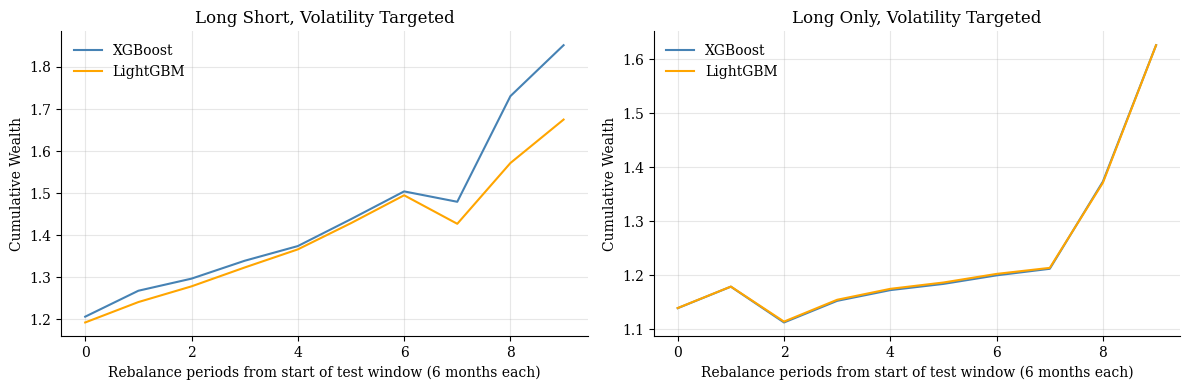

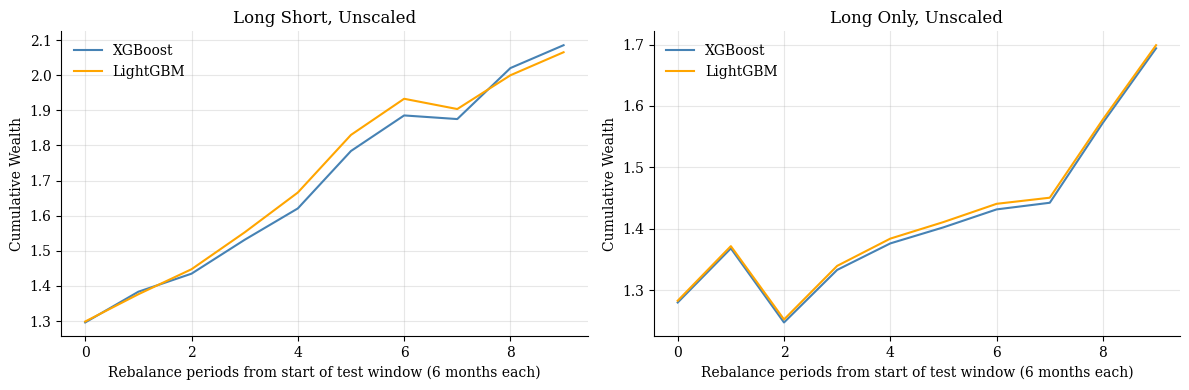

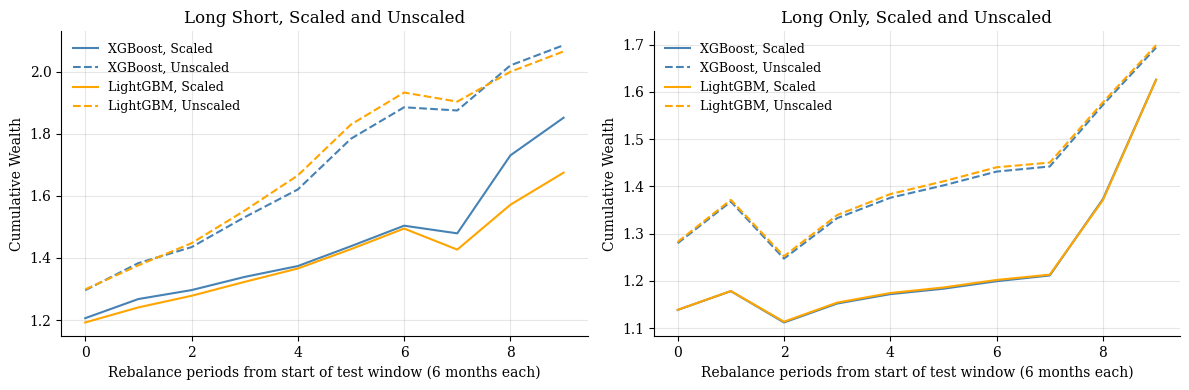

In [11]:
xgb_color = 'steelblue'
lgb_color = 'orange'
xlabel_periods = f'Rebalance periods from start of test window ({rebalance_freq} months each)'

# figure 1, volatility targeted
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_scaled']), label='XGBoost', color=xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_scaled']), label='LightGBM', color=lgb_color)
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_scaled']), label='XGBoost', color=xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_scaled']), label='LightGBM', color=lgb_color)
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_scaled.pdf')
fig.savefig(results_dir / 'tree_cumulative_scaled.png')
plt.show()
plt.close(fig)


# figure 2, unscaled
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_unscaled']), label='XGBoost', color=xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_unscaled']), label='LightGBM', color=lgb_color)
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_unscaled']), label='XGBoost', color=xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_unscaled']), label='LightGBM', color=lgb_color)
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_unscaled.pdf')
fig.savefig(results_dir / 'tree_cumulative_unscaled.png')
plt.show()
plt.close(fig)


# figure 3, scaled and unscaled overlaid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_scaled']), label='XGBoost, Scaled', color=xgb_color)
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--')
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_scaled']), label='LightGBM, Scaled', color=lgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--')
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Scaled and Unscaled')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_scaled']), label='XGBoost, Scaled', color=xgb_color)
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--')
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_scaled']), label='LightGBM, Scaled', color=lgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--')
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Scaled and Unscaled')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_combined.pdf')
fig.savefig(results_dir / 'tree_cumulative_combined.png')
plt.show()
plt.close(fig)


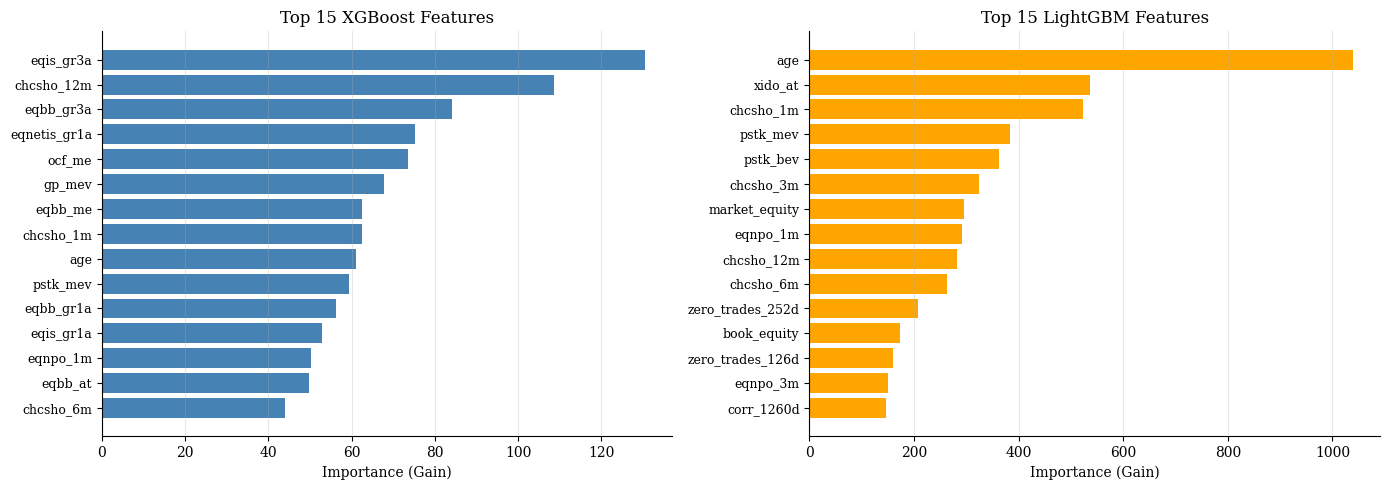

In [12]:
# xgboost and lightgbm feature importance, side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_xgb = xgb_imp.head(15)
ax = axes[0]
ax.barh(range(len(top_xgb)), top_xgb['importance'].to_numpy()[::-1], color=xgb_color)
ax.set_yticks(range(len(top_xgb)))
ax.set_yticklabels(top_xgb['feature'].to_numpy()[::-1], fontsize=9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 15 XGBoost Features')
ax.grid(axis='x', alpha=0.3)

top_lgb = lgb_imp.head(15)
ax = axes[1]
ax.barh(range(len(top_lgb)), top_lgb['importance'].to_numpy()[::-1], color=lgb_color)
ax.set_yticks(range(len(top_lgb)))
ax.set_yticklabels(top_lgb['feature'].to_numpy()[::-1], fontsize=9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 15 LightGBM Features')
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_feature_importance.pdf')
fig.savefig(results_dir / 'tree_feature_importance.png')
plt.show()
plt.close(fig)

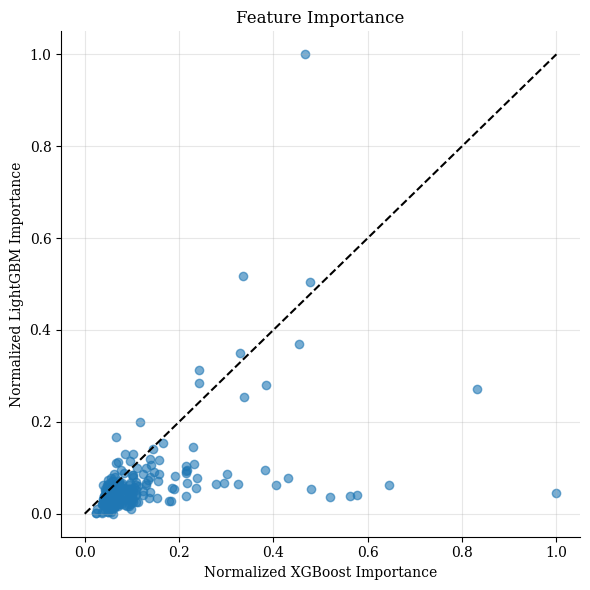

In [13]:
# Merge feature importances
cmp = (
    xgb_imp[['feature', 'importance']].rename(columns={'importance': 'XGBoost'})
    .merge(lgb_imp[['feature', 'importance']].rename(columns={'importance': 'LightGBM'}),on='feature',how='outer'
    ).fillna(0).set_index('feature'))

# Normalize importances
cmp['XGB'] = cmp['XGBoost'] / cmp['XGBoost'].max()
cmp['LGB'] = cmp['LightGBM'] / cmp['LightGBM'].max()

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(cmp['XGB'].to_numpy(), cmp['LGB'].to_numpy(), alpha=0.6)
ax.plot([0, 1], [0, 1], 'k--')

ax.set_xlabel('Normalized XGBoost Importance')
ax.set_ylabel('Normalized LightGBM Importance')
ax.set_title('Feature Importance')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'feature_importance_scatter.pdf')
fig.savefig(results_dir / 'feature_importance_scatter.png')

plt.show()
plt.close(fig)

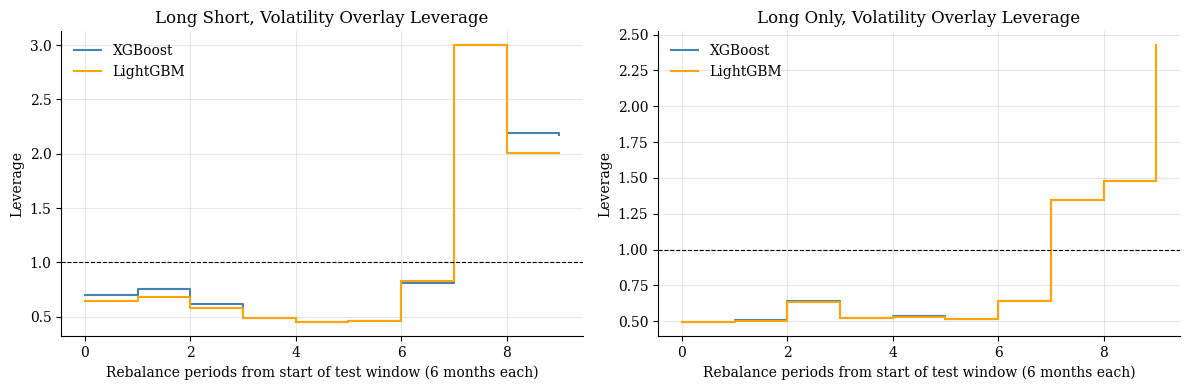

In [14]:
# leverage paths for xgboost and lightgbm, long-short and long-only
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.step(range(len(xgb_eval['leverage_ls'])), xgb_eval['leverage_ls'], where='post', color=xgb_color, label='XGBoost')
ax.step(range(len(lgb_eval['leverage_ls'])), lgb_eval['leverage_ls'], where='post', color=lgb_color, label='LightGBM')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Leverage')
ax.set_title('Long Short, Volatility Overlay Leverage')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.step(range(len(xgb_eval['leverage_lo'])), xgb_eval['leverage_lo'], where='post', color=xgb_color, label='XGBoost')
ax.step(range(len(lgb_eval['leverage_lo'])), lgb_eval['leverage_lo'], where='post', color=lgb_color, label='LightGBM')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Leverage')
ax.set_title('Long Only, Volatility Overlay Leverage')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_leverage.pdf')
fig.savefig(results_dir / 'tree_leverage.png')
plt.show()
plt.close(fig)

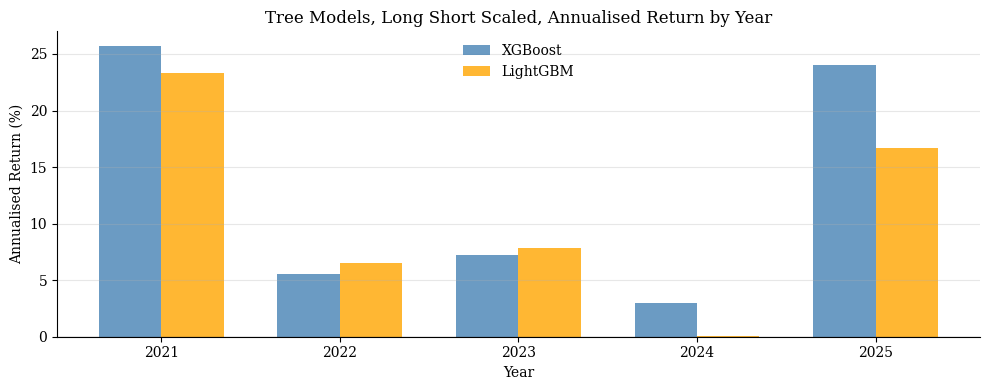

In [15]:
# per year annualised return: xgboost and lightgbm, long-short scaled
years_t = sorted(tree_per_year['year'].unique())
x_t = np.arange(len(years_t))
width_t = 0.35


def _tree_val(model, portfolio, scaling, year, col):
    sub = tree_per_year[
        (tree_per_year['model'] == model) &
        (tree_per_year['portfolio'] == portfolio) &
        (tree_per_year['scaling'] == scaling) &
        (tree_per_year['year'] == year)
    ]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


xgb_ls_yr = [_tree_val('xgboost', 'long_short', 'scaled', y, 'ann_ret') for y in years_t]
lgb_ls_yr = [_tree_val('lightgbm', 'long_short', 'scaled', y, 'ann_ret') for y in years_t]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_t - width_t / 2, xgb_ls_yr, width_t, label='XGBoost', color=xgb_color, alpha=0.8)
ax.bar(x_t + width_t / 2, lgb_ls_yr, width_t, label='LightGBM', color=lgb_color, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_t)
ax.set_xticklabels([str(y) for y in years_t])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Tree Models, Long Short Scaled, Annualised Return by Year')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_per_year_bar.pdf')
fig.savefig(results_dir / 'tree_per_year_bar.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

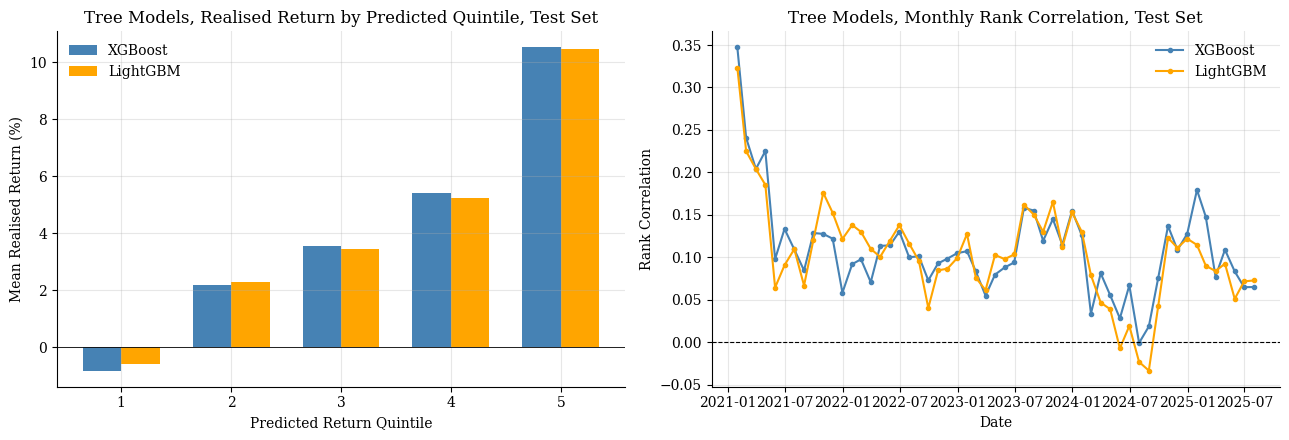

In [16]:
# read the per firm month test set predictions for each tree model.
# each read is defensive, since the exact output of tree_benchmark has
# not been directly verified against the notebook in this session.
def load_tree_predictions(path):
	try:
		df = pd.read_csv(path)
	except FileNotFoundError:
		print(f'{path.name} not found, skipping this diagnostic')
		return None
	df['eom'] = pd.to_datetime(df['eom'])
	return df


def monthly_rank_corr(df):
	rows = []
	for eom, group in df.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	return pd.DataFrame(rows).sort_values('eom')


xgb_test_pred = load_tree_predictions(tree_dir / 'xgb_test_predictions.csv')
lgb_test_pred = load_tree_predictions(tree_dir / 'lgb_test_predictions.csv')

if xgb_test_pred is not None and lgb_test_pred is not None:
	xgb_monthly_corr = monthly_rank_corr(xgb_test_pred)
	lgb_monthly_corr = monthly_rank_corr(lgb_test_pred)

	fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

	def quintile_mean_returns(df):
		def tag(group):
			group = group.copy()
			group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
			return group
		tagged = df.groupby('eom', group_keys = False).apply(tag)
		return tagged.groupby('quintile')['realised_return'].mean()

	xgb_quintile_returns = quintile_mean_returns(xgb_test_pred).reindex(range(1, 6))
	lgb_quintile_returns = quintile_mean_returns(lgb_test_pred).reindex(range(1, 6))
	quintile_x = np.arange(1, 6)
	quintile_width = 0.35

	ax = axes[0]
	ax.bar(quintile_x - quintile_width / 2, xgb_quintile_returns.to_numpy() * 100, quintile_width, color = xgb_color, label = 'XGBoost')
	ax.bar(quintile_x + quintile_width / 2, lgb_quintile_returns.to_numpy() * 100, quintile_width, color = lgb_color, label = 'LightGBM')
	ax.axhline(0, color = 'black', linewidth = 0.6)
	ax.set_xticks(quintile_x)
	ax.set_xlabel('Predicted Return Quintile')
	ax.set_ylabel('Mean Realised Return (%)')
	ax.set_title('Tree Models, Realised Return by Predicted Quintile, Test Set')
	ax.legend(frameon = False)
	ax.grid(alpha = 0.3)

	ax = axes[1]
	ax.plot(xgb_monthly_corr['eom'].to_numpy(), xgb_monthly_corr['rank_corr'].to_numpy(), color = xgb_color, marker = 'o', markersize = 3, label = 'XGBoost')
	ax.plot(lgb_monthly_corr['eom'].to_numpy(), lgb_monthly_corr['rank_corr'].to_numpy(), color = lgb_color, marker = 'o', markersize = 3, label = 'LightGBM')
	ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('Tree Models, Monthly Rank Correlation, Test Set')
	ax.legend(frameon = False)
	ax.grid(alpha = 0.3)

	fig.tight_layout()
	fig.savefig(results_dir / 'tree_prediction_summary.pdf')
	fig.savefig(results_dir / 'tree_prediction_summary.png')
	plt.show()
	plt.close(fig)


---
## Multi-Layer Perceptron

#### Hyperparameter

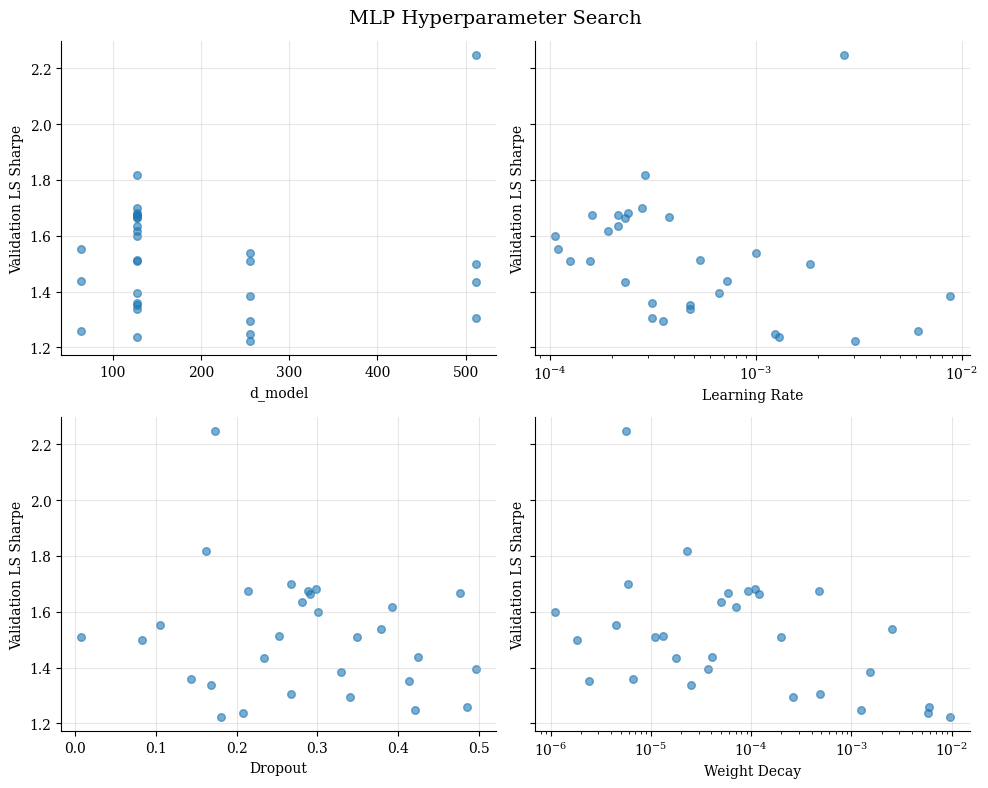

In [17]:
# mlp hpt convergence from saved optuna trials csv
mlp_plots_dir = Path('plots') / mlp_dir.name
mlp_plots_dir.mkdir(parents=True, exist_ok=True)
mlp_trials = pd.read_csv(mlp_dir / 'mlp_optuna_trials.csv')
mlp_color_h = 'darkgreen'

# MLP hyperparameter search
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
params = ['params_d_model', 'params_learning_rate', 'params_dropout', 'params_weight_decay']
labels = ['d_model', 'Learning Rate', 'Dropout', 'Weight Decay']

for ax, p, label in zip(axes.ravel(), params, labels):
    valid = mlp_trials[[p, 'value']].dropna()
    ax.scatter(valid[p].to_numpy(), valid['value'].to_numpy(), alpha=0.6, s=30)
    # Log scale for parameters spanning orders of magnitude
    if p in ['params_learning_rate', 'params_weight_decay']:
        ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('Validation LS Sharpe')
    ax.grid(alpha=0.3)

fig.suptitle('MLP Hyperparameter Search', fontsize=14)
fig.tight_layout()
fig.savefig(mlp_plots_dir / 'mlp_hyperparameter_scatter.pdf')
fig.savefig(mlp_plots_dir / 'mlp_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

In [18]:
mlp_ls_df = pd.read_csv(mlp_dir / 'mlp_returns_long_short.csv')
mlp_lo_df = pd.read_csv(mlp_dir / 'mlp_returns_long_only.csv')

mlp_eval = {
    'returns_ls_scaled': mlp_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': mlp_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': mlp_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': mlp_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': mlp_ls_df['leverage'].to_numpy(),
    'leverage_lo': mlp_lo_df['leverage'].to_numpy(),
}

mlp_per_year = pd.read_csv(mlp_dir / 'mlp_per_year_metrics.csv')
mlp_per_period = pd.read_csv(mlp_dir / 'mlp_per_period_metrics.csv')
mlp_per_month = pd.read_csv(mlp_dir / 'mlp_per_month_metrics.csv')
mlp_per_month['eom'] = pd.to_datetime(mlp_per_month['eom'])

with open(mlp_dir / 'mlp_train_log.json') as fh:
    mlp_train_log = json.load(fh)

mlp_summary = pd.read_csv(mlp_dir / 'mlp_summary.csv')

mlp_color = 'darkgreen'
rebalance_freq_mlp = 6
xlabel_periods_mlp = f'Rebalance periods from start of test window ({rebalance_freq_mlp} months each)'
results_dir_mlp = Path('plots') / mlp_dir.name
results_dir_mlp.mkdir(parents=True, exist_ok=True)

print(f'mlp periods: {len(mlp_ls_df)}, monthly rows: {len(mlp_per_month)}')
print(f'train epochs: {len(mlp_train_log["train_losses"])}')
print()
print('mlp benchmark headline summary')
print(mlp_summary.to_string(index=False))

mlp periods: 10, monthly rows: 220
train epochs: 3

mlp benchmark headline summary
model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cum_return  max_dd  n_obs
  mlp long_short unscaled   0.1287  2.0594 0.5586    10.91     5.30       68.99    1.20     10
  mlp long_short   scaled   0.1287  1.9472 0.5381    27.71    14.23      252.08    3.24     10
  mlp  long_only unscaled   0.1287  0.9348 0.3791    11.04    11.81       66.06    8.65     10
  mlp  long_only   scaled   0.1287  1.0271 0.3908    10.77    10.49       64.93    6.14     10


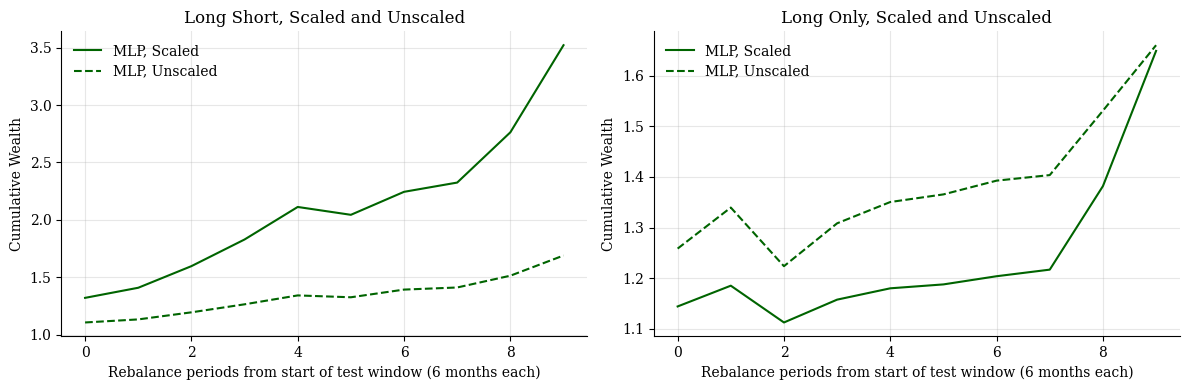

In [19]:
# mlp cumulative wealth, scaled and unscaled
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + mlp_eval['returns_ls_scaled']), label='MLP, Scaled', color=mlp_color)
ax.plot(np.cumprod(1 + mlp_eval['returns_ls_unscaled']), label='MLP, Unscaled', color=mlp_color, linestyle='--')
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Scaled and Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + mlp_eval['returns_lo_scaled']), label='MLP, Scaled', color=mlp_color)
ax.plot(np.cumprod(1 + mlp_eval['returns_lo_unscaled']), label='MLP, Unscaled', color=mlp_color, linestyle='--')
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Scaled and Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_cumulative_combined.pdf')
fig.savefig(results_dir_mlp / 'mlp_cumulative_combined.png')
plt.show()
plt.close(fig)

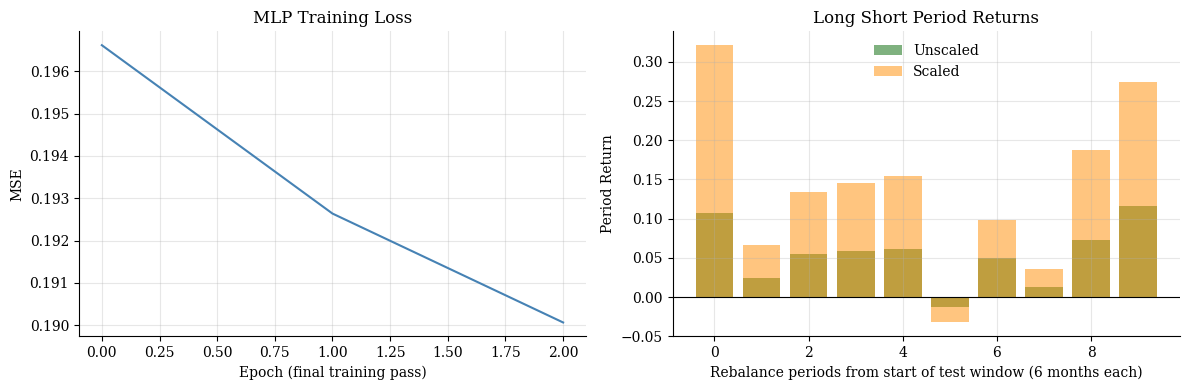

In [20]:
# mlp training loss and long-short period returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(mlp_train_log['train_losses'], color='steelblue')
ax.set_xlabel('Epoch (final training pass)')
ax.set_ylabel('MSE')
ax.set_title('MLP Training Loss')
ax.grid(alpha=0.3)

ax = axes[1]
ls_u = mlp_eval['returns_ls_unscaled']
ls_s = mlp_eval['returns_ls_scaled']
ax.bar(range(len(ls_u)), ls_u, alpha=0.5, color=mlp_color, label='Unscaled')
ax.bar(range(len(ls_s)), ls_s, alpha=0.5, color='darkorange', label='Scaled')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Period Return')
ax.set_title('Long Short Period Returns')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_summary.pdf')
fig.savefig(results_dir_mlp / 'mlp_summary.png')
plt.show()
plt.close(fig)

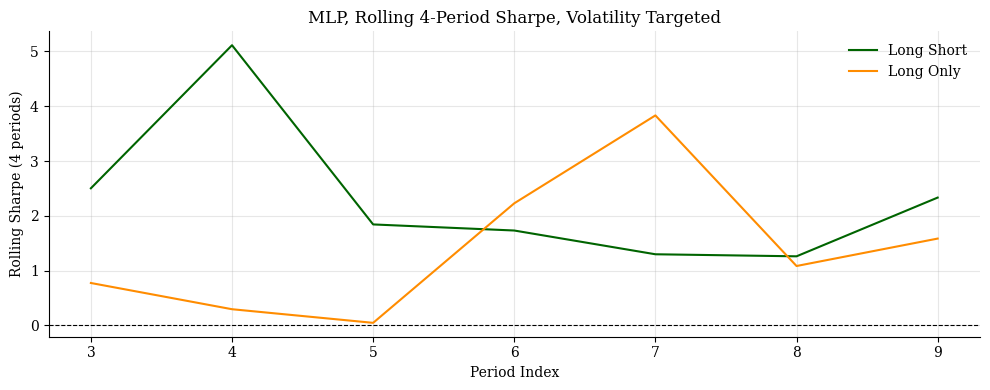

In [21]:
# rolling 4-period sharpe from per-period metrics (covers two calendar years)
mlp_ls_per = mlp_per_period[
    (mlp_per_period['portfolio'] == 'long_short') &
    (mlp_per_period['scaling'] == 'scaled')
].reset_index(drop=True)
mlp_lo_per = mlp_per_period[
    (mlp_per_period['portfolio'] == 'long_only') &
    (mlp_per_period['scaling'] == 'scaled')
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))

valid_ls = mlp_ls_per['rolling_sharpe_4p'].notna()
valid_lo = mlp_lo_per['rolling_sharpe_4p'].notna()

ax.plot(mlp_ls_per.index[valid_ls].to_numpy(), mlp_ls_per.loc[valid_ls, 'rolling_sharpe_4p'].to_numpy(),
        color=mlp_color, label='Long Short')
ax.plot(mlp_lo_per.index[valid_lo].to_numpy(), mlp_lo_per.loc[valid_lo, 'rolling_sharpe_4p'].to_numpy(),
        color='darkorange', label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Period Index')
ax.set_ylabel('Rolling Sharpe (4 periods)')
ax.set_title('MLP, Rolling 4-Period Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_rolling_period_sharpe.pdf')
fig.savefig(results_dir_mlp / 'mlp_rolling_period_sharpe.png')
plt.show()
plt.close(fig)

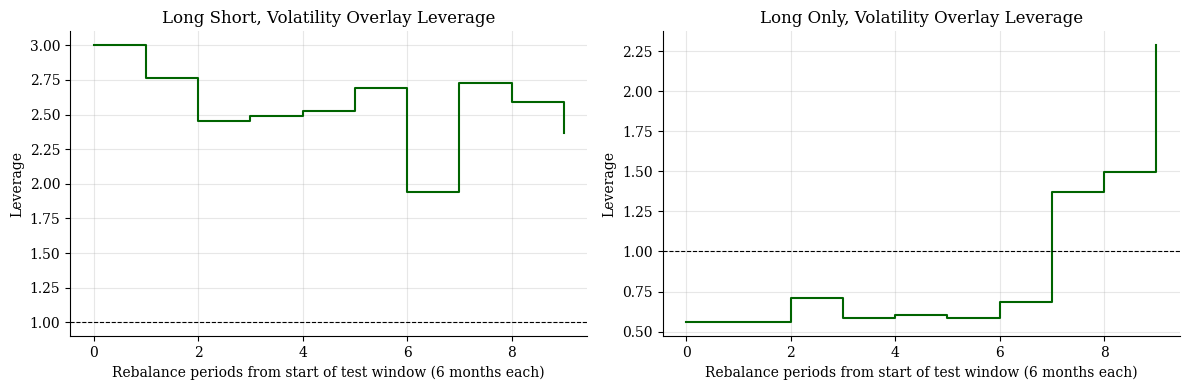

In [22]:
# mlp volatility overlay leverage path
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.step(range(len(mlp_eval['leverage_ls'])), mlp_eval['leverage_ls'], where='post', color=mlp_color)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Leverage')
ax.set_title('Long Short, Volatility Overlay Leverage')
ax.grid(alpha=0.3)

ax = axes[1]
ax.step(range(len(mlp_eval['leverage_lo'])), mlp_eval['leverage_lo'], where='post', color=mlp_color)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Leverage')
ax.set_title('Long Only, Volatility Overlay Leverage')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_leverage.pdf')
fig.savefig(results_dir_mlp / 'mlp_leverage.png')
plt.show()
plt.close(fig)

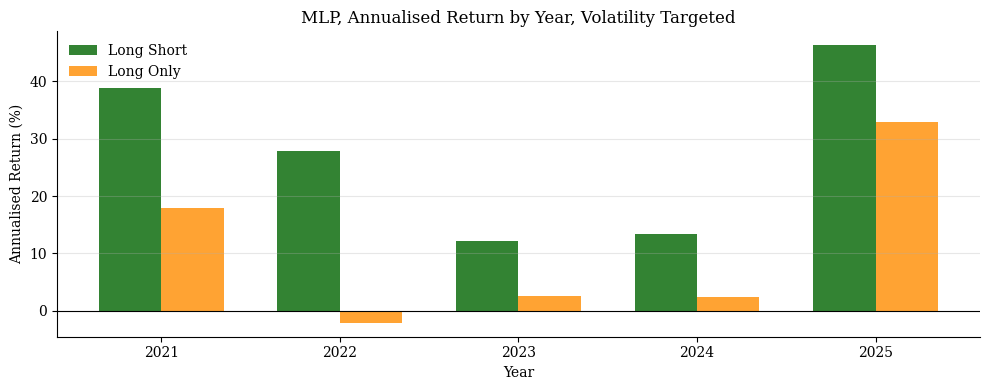

In [23]:
# mlp per year annualised return, long short and long only scaled
years_mlp = sorted(mlp_per_year['year'].unique())
x_mlp = np.arange(len(years_mlp))
width_mlp = 0.35


def _mlp_val(portfolio, year, col):
    sub = mlp_per_year[
        (mlp_per_year['portfolio'] == portfolio) &
        (mlp_per_year['scaling'] == 'scaled') &
        (mlp_per_year['year'] == year)
    ]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


ls_rets_mlp = [_mlp_val('long_short', y, 'ann_ret') for y in years_mlp]
lo_rets_mlp = [_mlp_val('long_only', y, 'ann_ret') for y in years_mlp]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_mlp - width_mlp / 2, ls_rets_mlp, width_mlp, label='Long Short', color=mlp_color, alpha=0.8)
ax.bar(x_mlp + width_mlp / 2, lo_rets_mlp, width_mlp, label='Long Only', color='darkorange', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_mlp)
ax.set_xticklabels([str(y) for y in years_mlp])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('MLP, Annualised Return by Year, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_per_year_bar.pdf')
fig.savefig(results_dir_mlp / 'mlp_per_year_bar.png')
plt.show()
plt.close(fig)

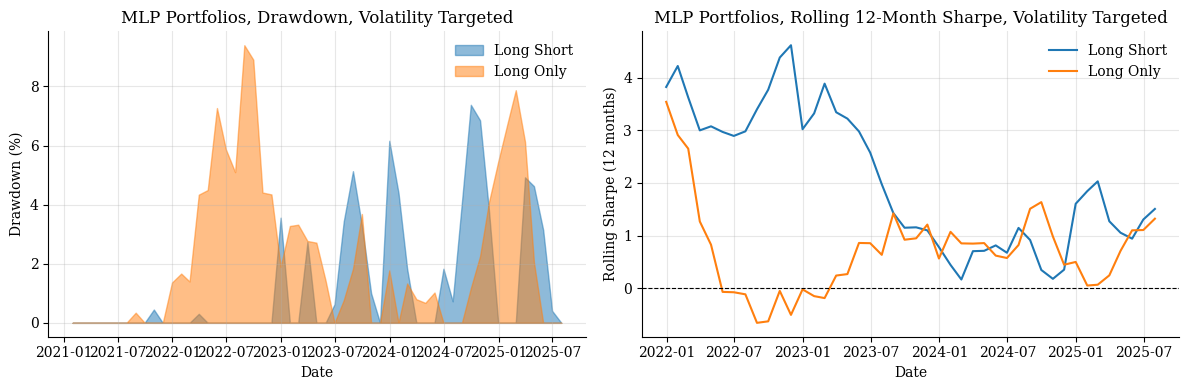

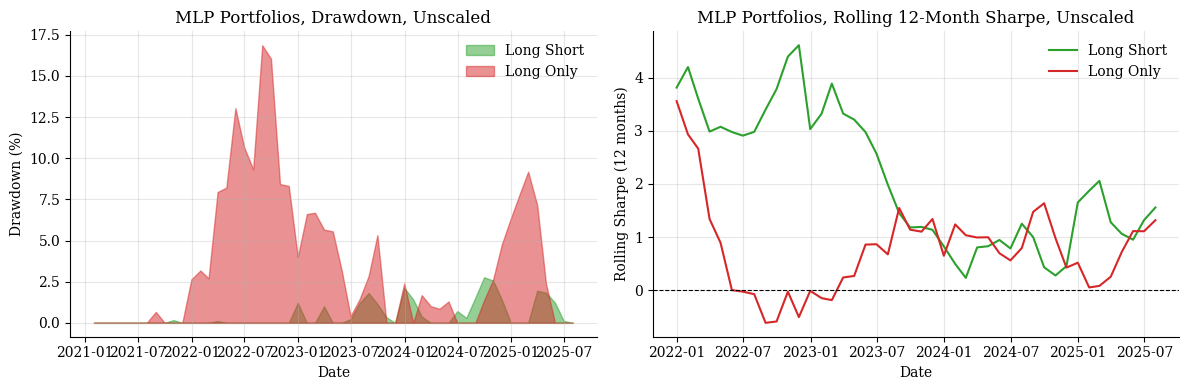

In [24]:
# MLP monthly drawdown and rolling 12-month Sharpe

mlp_ls_mo = mlp_per_month[
    (mlp_per_month['portfolio'] == 'long_short') &
    (mlp_per_month['scaling'] == 'scaled')
].sort_values('eom')

mlp_lo_mo = mlp_per_month[
    (mlp_per_month['portfolio'] == 'long_only') &
    (mlp_per_month['scaling'] == 'scaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Drawdown
ax = axes[0]
ax.fill_between(mlp_ls_mo['eom'].to_numpy(), mlp_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C0',label='Long Short')
ax.fill_between(mlp_lo_mo['eom'].to_numpy(),mlp_lo_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C1',label='Long Only')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios, Drawdown, Volatility Targeted')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# Rolling Sharpe
ax = axes[1]
valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'].to_numpy(), mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'].to_numpy(), color='C0', label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'].to_numpy(), mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'].to_numpy(), color='C1',label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios, Rolling 12-Month Sharpe, Volatility Targeted')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_monthly_summary.pdf')
fig.savefig(results_dir_mlp / 'mlp_monthly_summary.png')
plt.show()
plt.close(fig)

# MLP monthly drawdown and rolling 12-month Sharpe (Unscaled)

mlp_ls_mo = mlp_per_month[
    (mlp_per_month['portfolio'] == 'long_short') &
    (mlp_per_month['scaling'] == 'unscaled')
].sort_values('eom')

mlp_lo_mo = mlp_per_month[
    (mlp_per_month['portfolio'] == 'long_only') &
    (mlp_per_month['scaling'] == 'unscaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Drawdown
ax = axes[0]
ax.fill_between(mlp_ls_mo['eom'].to_numpy(), mlp_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C2', label='Long Short')
ax.fill_between(mlp_lo_mo['eom'].to_numpy(), mlp_lo_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C3', label='Long Only')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios, Drawdown, Unscaled')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# Rolling Sharpe
ax = axes[1]

valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'].to_numpy(), mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'].to_numpy(), color='C2', label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'].to_numpy(), mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'].to_numpy(), color='C3', label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios, Rolling 12-Month Sharpe, Unscaled')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_monthly_summary_unscaled.pdf')
fig.savefig(results_dir_mlp / 'mlp_monthly_summary_unscaled.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

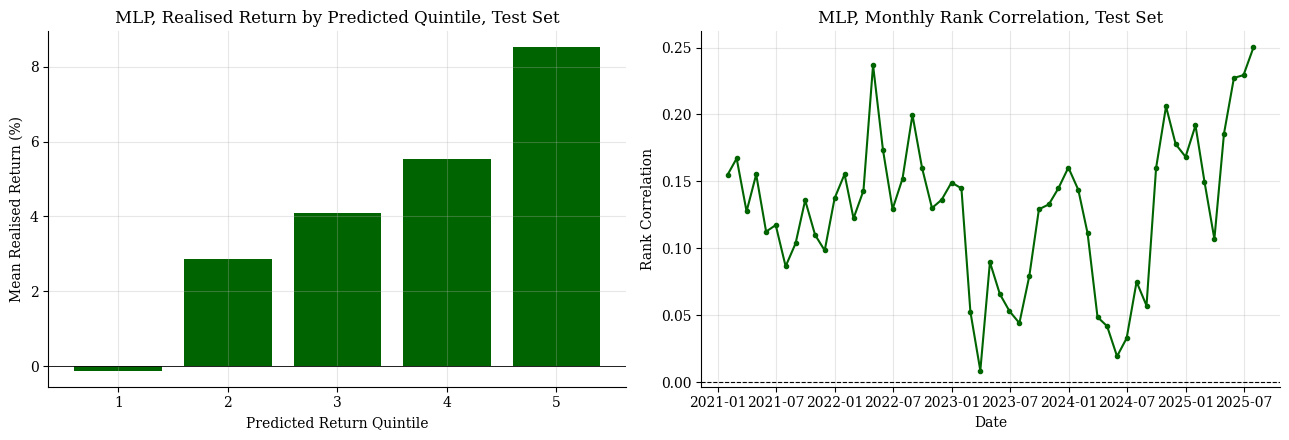

In [25]:
# defensive read of the per firm month test set predictions for the mlp
try:
	mlp_test_pred = pd.read_csv(mlp_dir / 'mlp_test_predictions.csv')
	mlp_test_pred['eom'] = pd.to_datetime(mlp_test_pred['eom'])
except FileNotFoundError:
	mlp_test_pred = None
	print('mlp_test_predictions.csv not found, skipping this diagnostic')

if mlp_test_pred is not None:
	rows = []
	for eom, group in mlp_test_pred.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	mlp_monthly_corr = pd.DataFrame(rows).sort_values('eom')

	fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

	def quintile_mean_returns(df):
		def tag(group):
			group = group.copy()
			group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
			return group
		tagged = df.groupby('eom', group_keys = False).apply(tag)
		return tagged.groupby('quintile')['realised_return'].mean()

	mlp_quintile_returns = quintile_mean_returns(mlp_test_pred)

	ax = axes[0]
	ax.bar(mlp_quintile_returns.index.to_numpy(), mlp_quintile_returns.to_numpy() * 100, color = mlp_color)
	ax.axhline(0, color = 'black', linewidth = 0.6)
	ax.set_xticks(range(1, 6))
	ax.set_xlabel('Predicted Return Quintile')
	ax.set_ylabel('Mean Realised Return (%)')
	ax.set_title('MLP, Realised Return by Predicted Quintile, Test Set')
	ax.grid(alpha = 0.3)

	ax = axes[1]
	ax.plot(mlp_monthly_corr['eom'].to_numpy(), mlp_monthly_corr['rank_corr'].to_numpy(), color = mlp_color, marker = 'o', markersize = 3)
	ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('MLP, Monthly Rank Correlation, Test Set')
	ax.grid(alpha = 0.3)

	fig.tight_layout()
	fig.savefig(results_dir_mlp / 'mlp_prediction_summary.pdf')
	fig.savefig(results_dir_mlp / 'mlp_prediction_summary.png')
	plt.show()
	plt.close(fig)


---
## FT-Transformer

#### Hyperparameter

In [26]:
ft_dir = Path('results/benchmark/ft_transformer_benchmark')
ft_plots_dir = Path('plots') / ft_dir.name
ft_plots_dir.mkdir(parents=True, exist_ok=True)
ft_color = 'royalblue'

ft_trials = pd.read_csv(ft_dir / 'ft_optuna_trials.csv')

with open(ft_dir / 'ft_best_params.json') as fh:
    ft_best_params_info = json.load(fh)

ft_study = None
try:
    with open(ft_dir / 'ft_optuna_study.pkl', 'rb') as fh:
        ft_study = pickle.load(fh)
    print('optuna study object loaded from pickle')
except Exception:
    print('optuna study pickle not available, csv-based hpt plot used instead')

ua = ft_best_params_info['best_trial_user_attrs']
print('ft-transformer, hyperparameter search summary')
print(f'best trial number, {ft_best_params_info["best_trial_number"]}')
print(f'best val long short sharpe, {ft_best_params_info["best_val_long_short_sharpe"]:.4f}')
print(f'val long only sharpe, {ua.get("val_sharpe_long_only", float("nan")):.4f}')
print(f'best epoch, {ua.get("best_epoch")}, epochs run, {ua.get("n_epochs_run")}')
print(f'd_model, {ua.get("d_model")}, d_ff, {ua.get("d_ff")}, param count, {ua.get("param_count")}')
print(f'best params, {ft_best_params_info["best_params"]}')
print(f'trials completed, {ft_best_params_info["n_trials_completed"]}')

optuna study object loaded from pickle
ft-transformer, hyperparameter search summary
best trial number, 16
best val long short sharpe, 2.7309
val long only sharpe, 0.5966
best epoch, 0, epochs run, 9
d_model, 32, d_ff, 128, param count, 44993
best params, {'n_heads': 4, 'd_model_per_head': 8, 'd_ff_ratio': 4, 'n_layers': 2, 'dropout': 0.251181647470428, 'batch_size': 128, 'learning_rate': 0.0009630619328293385, 'weight_decay': 1.755294192817726e-06}
trials completed, 30


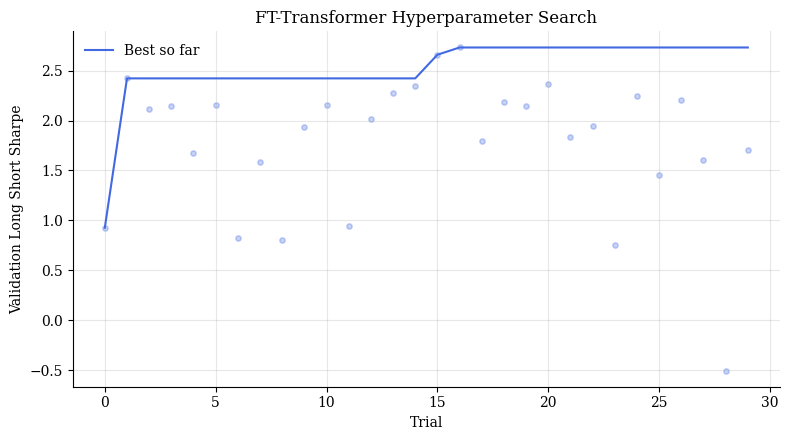

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ft_vals = ft_trials['value'].dropna().to_numpy()
ax.plot(np.maximum.accumulate(ft_vals), color=ft_color, linewidth=1.5, label='Best so far')
ax.scatter(range(len(ft_vals)), ft_vals, alpha=0.3, s=15, color=ft_color)
ax.set_xlabel('Trial')
ax.set_ylabel('Validation Long Short Sharpe')
ax.set_title('FT-Transformer Hyperparameter Search')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_hpt_convergence.pdf')
fig.savefig(ft_plots_dir / 'ft_hpt_convergence.png')
plt.show()
plt.close(fig)

### FT-Transformer

In [28]:
ft_ls_df = pd.read_csv(ft_dir / 'ft_returns_long_short.csv')
ft_lo_df = pd.read_csv(ft_dir / 'ft_returns_long_only.csv')
ft_ls_df['eom'] = pd.to_datetime(ft_ls_df['eom'])
ft_lo_df['eom'] = pd.to_datetime(ft_lo_df['eom'])

ft_holdings_ls = pd.read_csv(ft_dir / 'ft_holdings_long_short.csv')
ft_holdings_lo = pd.read_csv(ft_dir / 'ft_holdings_long_only.csv')

with open(ft_dir / 'ft_train_log.json') as fh:
    ft_train_log = json.load(fh)

ft_summary = pd.read_csv(ft_dir / 'ft_summary.csv')

rebalance_freq_ft = 6
xlabel_periods_ft = f'Rebalance periods from start of test window ({rebalance_freq_ft} months each)'

print(f'ft periods, {len(ft_ls_df)}')
print(f'train epochs, {len(ft_train_log["train_losses"])}')
print('ft-transformer benchmark headline summary')
print(ft_summary.to_string(index=False))

ft periods, 9
train epochs, 11
ft-transformer benchmark headline summary
 portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  max_dd  n_obs
long_short unscaled   0.1551  2.3589 0.6483    18.30     7.76 18.88    0.00      9
long_short   scaled   0.1551  1.4156 0.4716    31.17    22.02 31.71    0.00      9
 long_only unscaled   0.1551  1.0227 0.4114    14.56    14.24 14.23    7.42      9
 long_only   scaled   0.1551  1.1051 0.4230     9.24     8.36  9.15    4.41      9


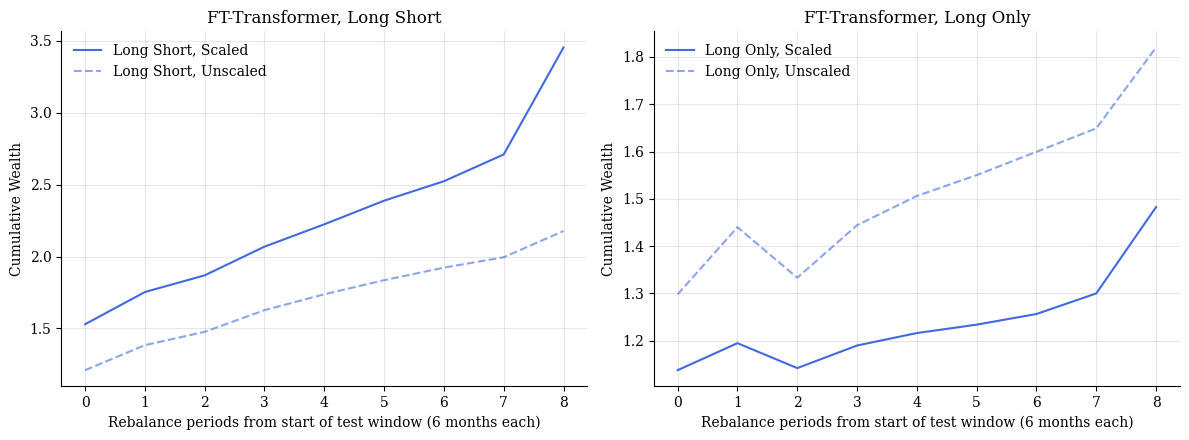

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(np.cumprod(1 + ft_ls_df['return_scaled'].to_numpy()), label='Long Short, Scaled', color=ft_color)
ax.plot(np.cumprod(1 + ft_ls_df['return_unscaled'].to_numpy()), label='Long Short, Unscaled', color=ft_color, linestyle='--', alpha=0.6)
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Short')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + ft_lo_df['return_scaled'].to_numpy()), label='Long Only, Scaled', color=ft_color)
ax.plot(np.cumprod(1 + ft_lo_df['return_unscaled'].to_numpy()), label='Long Only, Unscaled', color=ft_color, linestyle='--', alpha=0.6)
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Only')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_cumulative_wealth.pdf')
fig.savefig(ft_plots_dir / 'ft_cumulative_wealth.png')
plt.show()
plt.close(fig)

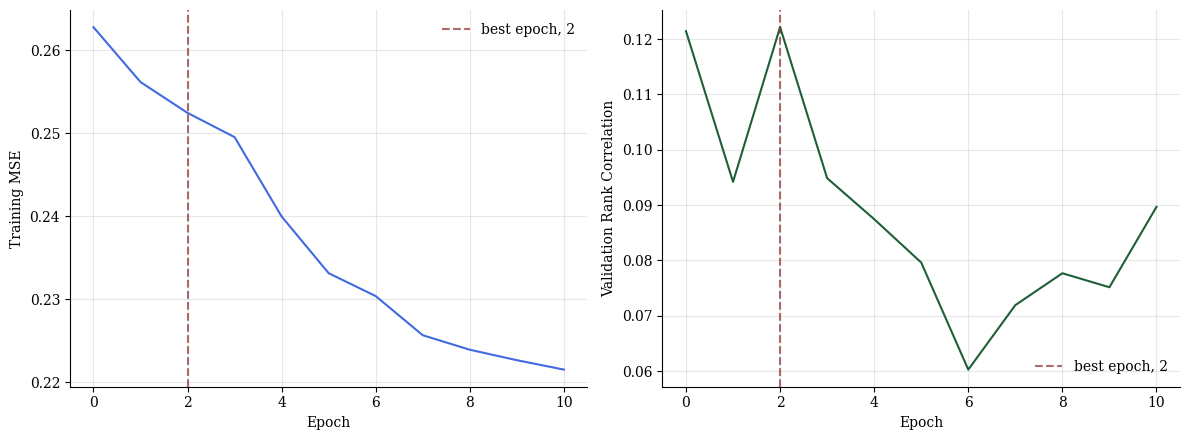

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ft_train_log['train_losses'], color=ft_color)
axes[0].axvline(ft_train_log['best_epoch'], color='#8B2D2D', linestyle='--', alpha=0.7, label=f'best epoch, {ft_train_log["best_epoch"]}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training MSE')
axes[0].legend(frameon=False, loc='upper right')
axes[0].grid(alpha=0.3)

axes[1].plot(ft_train_log['val_rank_corr'], color='#1E5F38')
axes[1].axvline(ft_train_log['best_epoch'], color='#8B2D2D', linestyle='--', alpha=0.7, label=f'best epoch, {ft_train_log["best_epoch"]}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Rank Correlation')
axes[1].legend(frameon=False, loc='lower right')
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_training_summary.pdf')
fig.savefig(ft_plots_dir / 'ft_training_summary.png')
plt.show()
plt.close(fig)

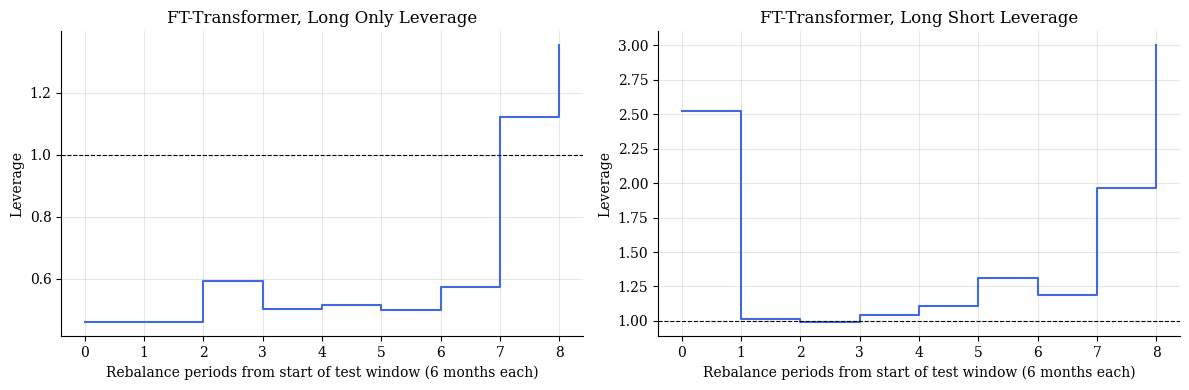

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.step(range(len(ft_lo_df)), ft_lo_df['leverage'].to_numpy(), where='post', color=ft_color)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Leverage')
ax.set_title('FT-Transformer, Long Only Leverage')
ax.grid(alpha=0.3)

ax = axes[1]
ax.step(range(len(ft_ls_df)), ft_ls_df['leverage'].to_numpy(), where='post', color=ft_color)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Leverage')
ax.set_title('FT-Transformer, Long Short Leverage')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_leverage.pdf')
fig.savefig(ft_plots_dir / 'ft_leverage.png')
plt.show()
plt.close(fig)

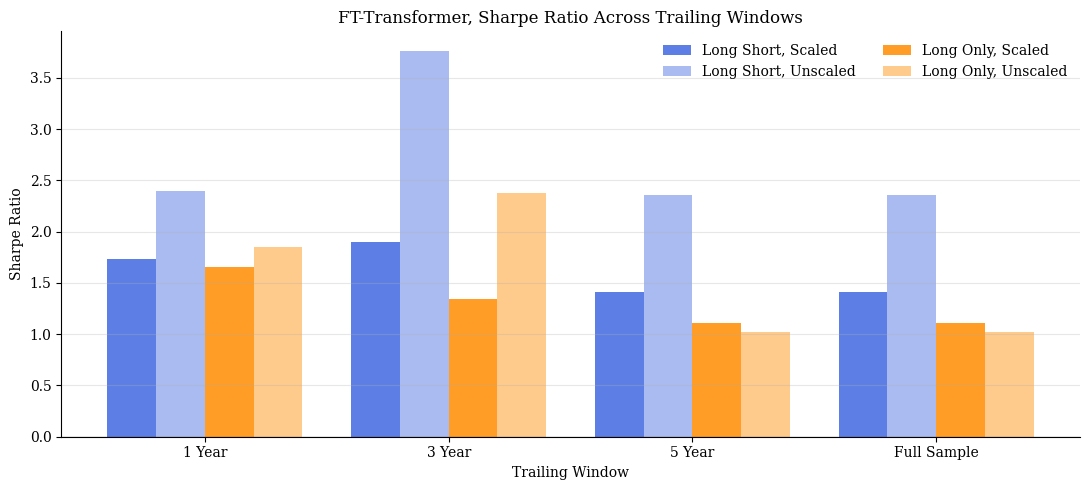

In [32]:
def ft_trailing_sharpe(returns, periods_per_year, n_periods):
	window = returns[-n_periods:] if len(returns) >= n_periods else returns
	if len(window) < 2:
		return float('nan')
	ann_ret = float(np.mean(window) * periods_per_year)
	ann_vol = float(np.std(window, ddof = 1) * np.sqrt(periods_per_year))
	return ann_ret / ann_vol if ann_vol > 0 else float('nan')


ls_scaled_returns = ft_ls_df['return_scaled'].to_numpy()
ls_unscaled_returns = ft_ls_df['return_unscaled'].to_numpy()
lo_scaled_returns = ft_lo_df['return_scaled'].to_numpy()
lo_unscaled_returns = ft_lo_df['return_unscaled'].to_numpy()
periods_per_year_ft = 12.0 / rebalance_freq_ft
window_months_ft = {'sharpe_1y': 12, 'sharpe_3y': 36, 'sharpe_5y': 60}

windows = ['sharpe_1y', 'sharpe_3y', 'sharpe_5y', 'sharpe']
window_labels = ['1 Year', '3 Year', '5 Year', 'Full Sample']
x_ft = np.arange(len(windows))
width_ft = 0.2


def ft_window_periods(key, returns):
	if key == 'sharpe':
		return len(returns)
	return max(1, window_months_ft[key] // rebalance_freq_ft)


ls_scaled_window_vals = [ft_trailing_sharpe(ls_scaled_returns, periods_per_year_ft, ft_window_periods(w, ls_scaled_returns)) for w in windows]
ls_unscaled_window_vals = [ft_trailing_sharpe(ls_unscaled_returns, periods_per_year_ft, ft_window_periods(w, ls_unscaled_returns)) for w in windows]
lo_scaled_window_vals = [ft_trailing_sharpe(lo_scaled_returns, periods_per_year_ft, ft_window_periods(w, lo_scaled_returns)) for w in windows]
lo_unscaled_window_vals = [ft_trailing_sharpe(lo_unscaled_returns, periods_per_year_ft, ft_window_periods(w, lo_unscaled_returns)) for w in windows]

fig, ax = plt.subplots(figsize = (11, 5))
ax.bar(x_ft - 1.5 * width_ft, ls_scaled_window_vals, width_ft, label = 'Long Short, Scaled', color = ft_color, alpha = 0.85)
ax.bar(x_ft - 0.5 * width_ft, ls_unscaled_window_vals, width_ft, label = 'Long Short, Unscaled', color = ft_color, alpha = 0.45)
ax.bar(x_ft + 0.5 * width_ft, lo_scaled_window_vals, width_ft, label = 'Long Only, Scaled', color = 'darkorange', alpha = 0.85)
ax.bar(x_ft + 1.5 * width_ft, lo_unscaled_window_vals, width_ft, label = 'Long Only, Unscaled', color = 'darkorange', alpha = 0.45)
ax.axhline(0, color = 'black', linewidth = 0.8)
ax.set_xticks(x_ft)
ax.set_xticklabels(window_labels)
ax.set_xlabel('Trailing Window')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('FT-Transformer, Sharpe Ratio Across Trailing Windows')
ax.legend(frameon = False, ncol = 2)
ax.grid(axis = 'y', alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_trailing_sharpe_windows.pdf')
fig.savefig(ft_plots_dir / 'ft_trailing_sharpe_windows.png')
plt.show()
plt.close(fig)

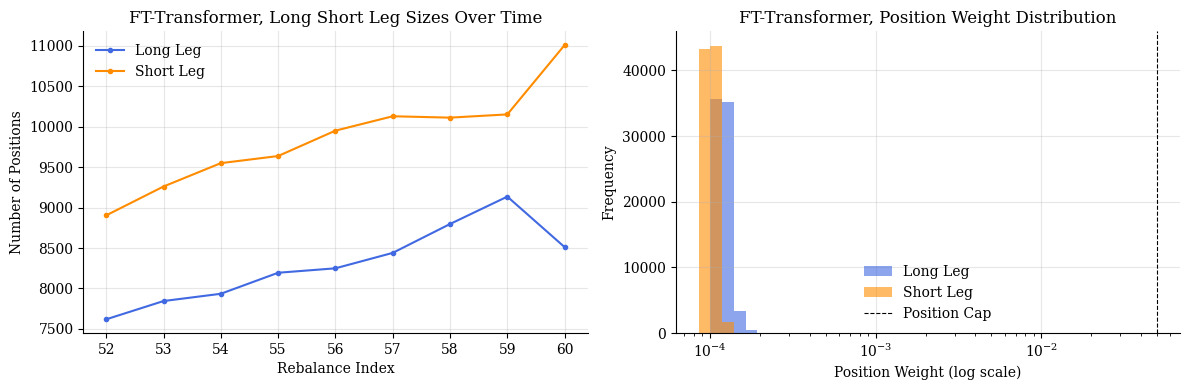

In [33]:
leg_counts_ft = ft_holdings_ls.groupby(['rebalance_index', 'leg']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
if 'long' in leg_counts_ft.columns:
    ax.plot(leg_counts_ft.index.to_numpy(), leg_counts_ft['long'].to_numpy(), color=ft_color, label='Long Leg', marker='o', markersize=3)
if 'short' in leg_counts_ft.columns:
    ax.plot(leg_counts_ft.index.to_numpy(), leg_counts_ft['short'].to_numpy(), color='darkorange', label='Short Leg', marker='o', markersize=3)
ax.set_xlabel('Rebalance Index')
ax.set_ylabel('Number of Positions')
ax.set_title('FT-Transformer, Long Short Leg Sizes Over Time')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ft_long_weights = ft_holdings_ls.loc[ft_holdings_ls['leg'] == 'long', 'weight'].to_numpy()
ft_short_weights = ft_holdings_ls.loc[ft_holdings_ls['leg'] == 'short', 'weight'].abs().to_numpy()
min_weight = min(ft_long_weights.min(), ft_short_weights.min())
bins = np.logspace(np.log10(min_weight), np.log10(0.05), 40)
ax.hist(ft_long_weights, bins=bins, alpha=0.6, color=ft_color, label='Long Leg')
ax.hist(ft_short_weights, bins=bins, alpha=0.6, color='darkorange', label='Short Leg')
ax.axvline(0.05, color='black', linewidth=0.8, linestyle='--', label='Position Cap')
ax.set_xscale('log')
ax.set_xlabel('Position Weight (log scale)')
ax.set_ylabel('Frequency')
ax.set_title('FT-Transformer, Position Weight Distribution')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_holdings_summary.pdf')
fig.savefig(ft_plots_dir / 'ft_holdings_summary.png')
plt.show()
plt.close(fig)

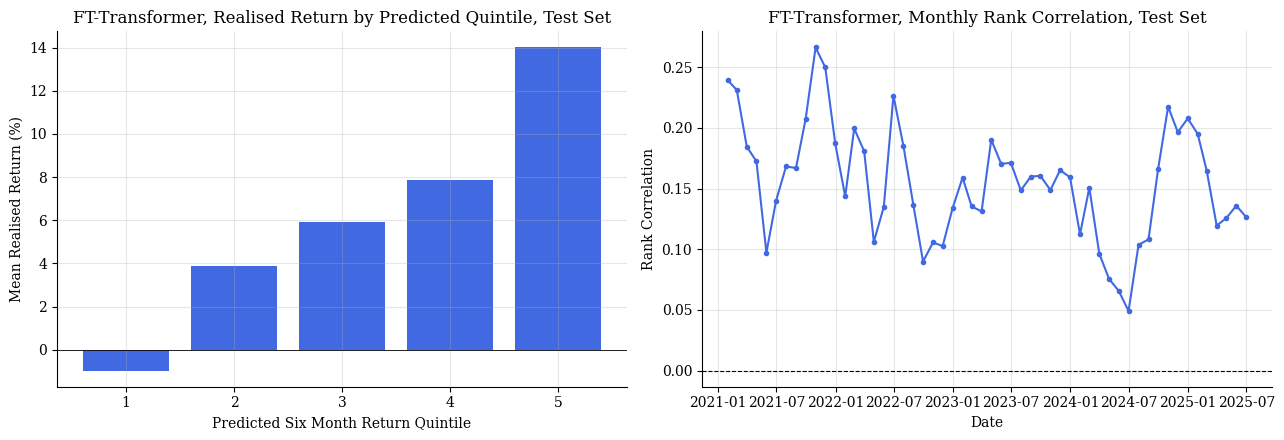

In [34]:
ft_test_pred = pd.read_csv(ft_dir / 'ft_test_predictions.csv')
ft_test_pred['eom'] = pd.to_datetime(ft_test_pred['eom'])

monthly_corr_rows = []
for eom, group in ft_test_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
	monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_monthly_corr = pd.DataFrame(monthly_corr_rows).sort_values('eom')


def ft_quintile_mean_returns(df):
	def tag(group):
		group = group.copy()
		group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
		return group
	tagged = df.groupby('eom', group_keys = False).apply(tag)
	return tagged.groupby('quintile')['realised_return'].mean()


ft_quintile_returns = ft_quintile_mean_returns(ft_test_pred)

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

ax = axes[0]
ax.bar(ft_quintile_returns.index.to_numpy(), ft_quintile_returns.to_numpy() * 100, color = ft_color)
ax.axhline(0, color = 'black', linewidth = 0.6)
ax.set_xticks(range(1, 6))
ax.set_xlabel('Predicted Six Month Return Quintile')
ax.set_ylabel('Mean Realised Return (%)')
ax.set_title('FT-Transformer, Realised Return by Predicted Quintile, Test Set')
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color = ft_color, marker = 'o', markersize = 3)
ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Test Set')
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_prediction_summary.pdf')
fig.savefig(ft_plots_dir / 'ft_prediction_summary.png')
plt.show()
plt.close(fig)


#### Validation Diagnostics

In [35]:
with open(ft_dir / 'ft_summary.json') as fh:
	ft_summary_full = json.load(fh)

with open(ft_dir / 'ft_splits.json') as fh:
	ft_splits = json.load(fh)

with open(ft_dir / 'ft_feature_cols.json') as fh:
	ft_feature_cols_info = json.load(fh)

ft_val_pred = pd.read_csv(ft_dir / 'ft_val_predictions.csv')
ft_val_pred['eom'] = pd.to_datetime(ft_val_pred['eom'])

ft_arch = ft_summary_full['architecture']
ft_config = ft_summary_full['config']

print('ft-transformer, architecture summary')
print(f'reference, {ft_arch["reference"]}')
print(f'n_heads, {ft_arch["n_heads"]}, d_model, {ft_arch["d_model"]}, d_ff, {ft_arch["d_ff"]}, n_layers, {ft_arch["n_layers"]}, dropout, {ft_arch["dropout"]}')
print(f'parameter count, {ft_arch["parameter_count"]:,}')
print(f'n_features, {ft_feature_cols_info["n_features"]}')
print()
print('ft-transformer, split summary')
print(f'train, {ft_splits["train_start"]} to {ft_splits["train_end"]}, {ft_splits["n_train_months"]} months')
print(f'val, {ft_splits["val_start"]} to {ft_splits["val_end"]}, {ft_splits["n_val_months"]} months')
print(f'test, {ft_splits["test_start"]} to {ft_splits["test_end"]}, {ft_splits["n_test_months"]} months')
print()
print('ft-transformer, portfolio configuration')
print(f'target vol, {ft_config["target_vol"]}, vol lookback months, {ft_config["vol_lookback_months"]}, max position weight, {ft_config["max_position_weight"]}')
print(f'max leverage long only, {ft_config["max_leverage_long_only"]}, max leverage long short, {ft_config["max_leverage_long_short"]}, tc bps, {ft_config["tc_bps"]}')
print()
print(f'final training time seconds, {ft_train_log["training_time_seconds"]:.1f}, parameter count (train log), {ft_train_log["parameter_count"]:,}')
print(f'best val rank corr, {ft_train_log["best_val_rc"]:.4f}, rc_val, {ft_summary_full["ft_transformer"]["rc_val"]:.4f}, rc_test, {ft_summary_full["ft_transformer"]["rc_test"]:.4f}')


ft-transformer, architecture summary
reference, Gorishniy et al. (2021)
n_heads, 4, d_model, 32, d_ff, 128, n_layers, 2, dropout, 0.251181647470428
parameter count, 44,993
n_features, 304

ft-transformer, split summary
train, 1995-01-31 to 2015-12-31, 252 months
val, 2016-01-31 to 2020-12-31, 60 months
test, 2021-01-31 to 2025-06-30, 54 months

ft-transformer, portfolio configuration
target vol, 0.1, vol lookback months, 36, max position weight, 0.05
max leverage long only, 3.0, max leverage long short, 3.0, tc bps, 25

final training time seconds, 604.8, parameter count (train log), 44,993
best val rank corr, 0.1222, rc_val, 0.1222, rc_test, 0.1551


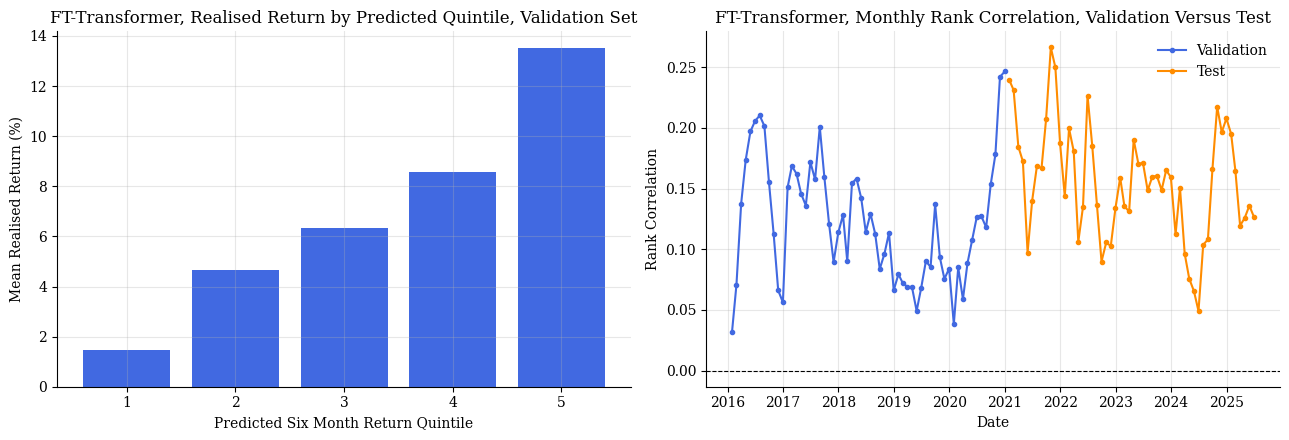

In [36]:
val_monthly_corr_rows = []
for eom, group in ft_val_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
	val_monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_val_monthly_corr = pd.DataFrame(val_monthly_corr_rows).sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

ft_val_quintile_returns = ft_quintile_mean_returns(ft_val_pred)

ax = axes[0]
ax.bar(ft_val_quintile_returns.index.to_numpy(), ft_val_quintile_returns.to_numpy() * 100, color = ft_color)
ax.axhline(0, color = 'black', linewidth = 0.6)
ax.set_xticks(range(1, 6))
ax.set_xlabel('Predicted Six Month Return Quintile')
ax.set_ylabel('Mean Realised Return (%)')
ax.set_title('FT-Transformer, Realised Return by Predicted Quintile, Validation Set')
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(ft_val_monthly_corr['eom'].to_numpy(), ft_val_monthly_corr['rank_corr'].to_numpy(), color = ft_color, marker = 'o', markersize = 3, label = 'Validation')
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color = 'darkorange', marker = 'o', markersize = 3, label = 'Test')
ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Validation Versus Test')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_validation_prediction_summary.pdf')
fig.savefig(ft_plots_dir / 'ft_validation_prediction_summary.png')
plt.show()
plt.close(fig)


#### Long Only Holdings

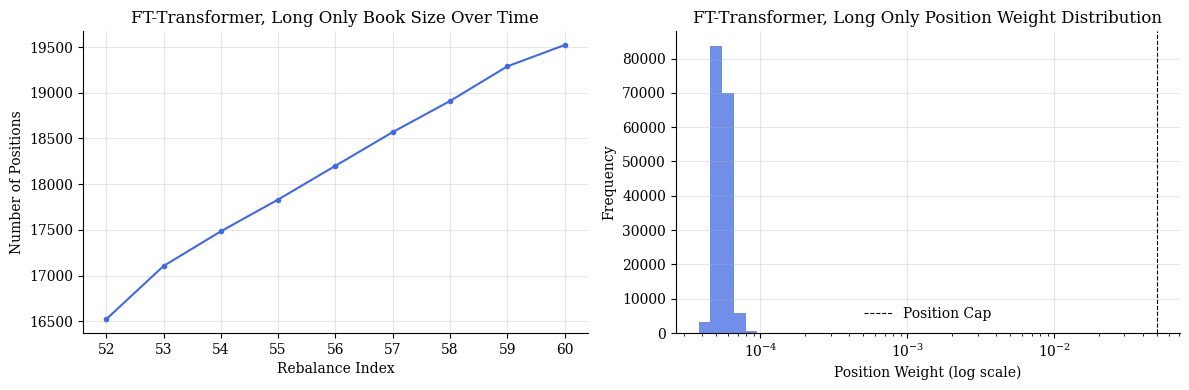

In [37]:
leg_counts_ft_lo = ft_holdings_lo.groupby('rebalance_index').size()

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(leg_counts_ft_lo.index.to_numpy(), leg_counts_ft_lo.to_numpy(), color = ft_color, marker = 'o', markersize = 3)
ax.set_xlabel('Rebalance Index')
ax.set_ylabel('Number of Positions')
ax.set_title('FT-Transformer, Long Only Book Size Over Time')
ax.grid(alpha = 0.3)

ax = axes[1]
lo_weights = ft_holdings_lo['weight'].to_numpy()
bins = np.logspace(np.log10(lo_weights.min()), np.log10(0.05), 40)
ax.hist(lo_weights, bins = bins, alpha = 0.75, color = ft_color)
ax.axvline(0.05, color = 'black', linewidth = 0.8, linestyle = '--', label = 'Position Cap')
ax.set_xscale('log')
ax.set_xlabel('Position Weight (log scale)')
ax.set_ylabel('Frequency')
ax.set_title('FT-Transformer, Long Only Position Weight Distribution')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_long_only_holdings_summary.pdf')
fig.savefig(ft_plots_dir / 'ft_long_only_holdings_summary.png')
plt.show()
plt.close(fig)


---
## Dual Path Portfolio Transformer

#### Hyperparameter

In [38]:
dppt_hpt_dir = Path('results/transformer-hpt')
dppt_eval_dir = Path('results/transformer')
dppt_hpt_plots_dir = Path('plots') / dppt_hpt_dir.name
dppt_eval_plots_dir = Path('plots') / dppt_eval_dir.name
dppt_hpt_plots_dir.mkdir(parents=True, exist_ok=True)
dppt_eval_plots_dir.mkdir(parents=True, exist_ok=True)
dppt_variant_order = ['linear', 'per_feature', 'ple', 'periodic', 'fourier']
dppt_color_map = {v: f'C{k}' for k, v in enumerate(dppt_variant_order)}

master_path = dppt_hpt_dir / 'all_trials_summary.csv'
if master_path.exists():
    dppt_all_trials = pd.read_csv(master_path)
else:
    trial_frames = []
    for variant in dppt_variant_order:
        trial_path = dppt_hpt_dir / f'trials_{variant}.csv'
        if trial_path.exists():
            trial_frames.append(pd.read_csv(trial_path))
    dppt_all_trials = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()

dppt_best_params = {}
dppt_epoch_history = {}
for variant in dppt_variant_order:
    params_path = dppt_hpt_dir / f'best_params_{variant}.json'
    epoch_path = dppt_hpt_dir / f'epoch_history_{variant}.csv'
    if params_path.exists():
        with open(params_path) as fh:
            dppt_best_params[variant] = json.load(fh)
    if epoch_path.exists():
        dppt_epoch_history[variant] = pd.read_csv(epoch_path)

dppt_variants_hpt = [v for v in dppt_variant_order if v in dppt_best_params]

summary_rows = []
for variant in dppt_variants_hpt:
    p = dppt_best_params[variant]
    summary_rows.append({
        'variant': variant,
        'trial_number': p.get('trial_number'),
        'd_model': p.get('d_model'),
        'n_heads': p.get('n_heads'),
        'n_layers': p.get('n_layers'),
        'lr': round(p.get('lr', float('nan')), 6),
        'best_epoch': p.get('best_epoch'),
        'n_epochs_trained': p.get('n_epochs_trained'),
        'val_sharpe_ls': round(p.get('best_val_sharpe_ls', float('nan')), 4),
        'corr_6m': round(p.get('best_corr_6m', float('nan')), 4),
        'base_corr_6m': round(p.get('best_base_corr_6m', float('nan')), 4),
    })
dppt_hpt_summary = pd.DataFrame(summary_rows)
print('dual path portfolio transformer, hyperparameter search summary')
print(dppt_hpt_summary.to_string(index=False))

dual path portfolio transformer, hyperparameter search summary
Empty DataFrame
Columns: []
Index: []


/var/folders/ng/4mdk7q7d2hschz1nhvq8_vmm0000gn/T/ipykernel_45724/1457981391.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


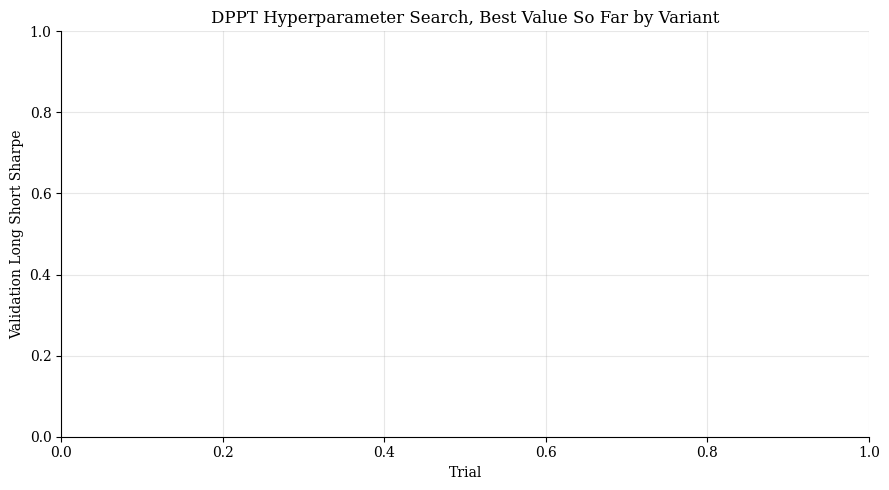

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
for variant in dppt_variants_hpt:
    sub = dppt_all_trials[dppt_all_trials['variant'] == variant].sort_values('number')
    vals = sub['value'].dropna().to_numpy()
    if len(vals) == 0:
        continue
    ax.plot(np.maximum.accumulate(vals), color=dppt_color_map[variant], label=variant, linewidth=1.5)
ax.set_xlabel('Trial')
ax.set_ylabel('Validation Long Short Sharpe')
ax.set_title('DPPT Hyperparameter Search, Best Value So Far by Variant')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_hpt_plots_dir / 'dppt_hpt_convergence.pdf')
fig.savefig(dppt_hpt_plots_dir / 'dppt_hpt_convergence.png')
plt.show()
plt.close(fig)

/var/folders/ng/4mdk7q7d2hschz1nhvq8_vmm0000gn/T/ipykernel_45724/1995945661.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False, fontsize=8)
/var/folders/ng/4mdk7q7d2hschz1nhvq8_vmm0000gn/T/ipykernel_45724/1995945661.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False, fontsize=8)


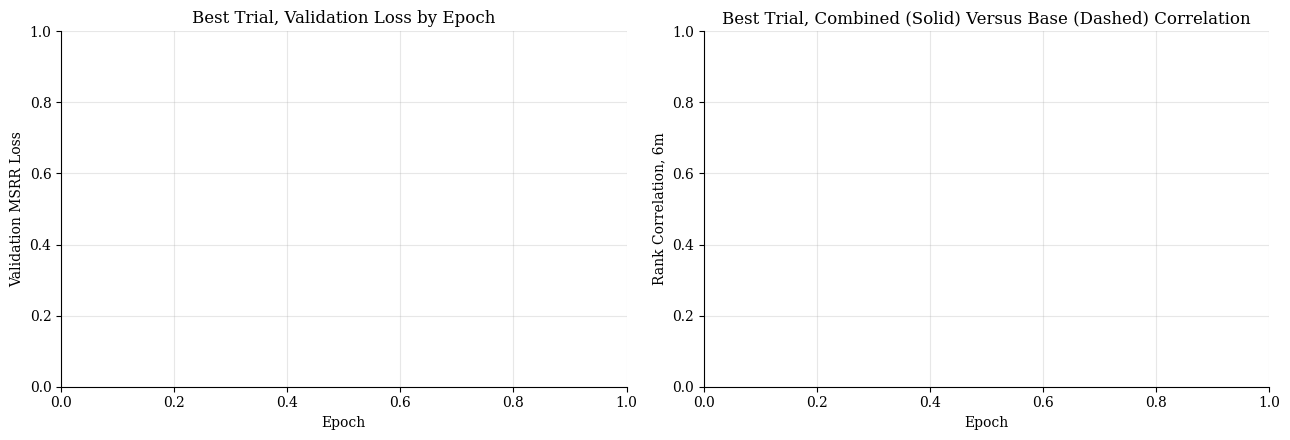

In [40]:
# validation loss and combined versus base rank correlation across epochs,
# for the best trial of each variant
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for variant in dppt_variants_hpt:
    if variant not in dppt_epoch_history:
        continue
    best_trial_num = dppt_best_params[variant].get('trial_number')
    eh = dppt_epoch_history[variant]
    sub = eh[eh['trial_number'] == best_trial_num].sort_values('epoch')
    if len(sub) == 0:
        continue
    color = dppt_color_map[variant]
    axes[0].plot(sub['epoch'].to_numpy(), sub['val_loss'].to_numpy(), color=color, label=variant)
    axes[1].plot(sub['epoch'].to_numpy(), sub['corr_6m'].to_numpy(), color=color, label=variant)
    axes[1].plot(sub['epoch'].to_numpy(), sub['base_corr_6m'].to_numpy(), color=color, linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation MSRR Loss')
axes[0].set_title('Best Trial, Validation Loss by Epoch')
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Rank Correlation, 6m')
axes[1].set_title('Best Trial, Combined (Solid) Versus Base (Dashed) Correlation')
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_hpt_plots_dir / 'dppt_best_trial_epoch_curves.pdf')
fig.savefig(dppt_hpt_plots_dir / 'dppt_best_trial_epoch_curves.png')
plt.show()
plt.close(fig)

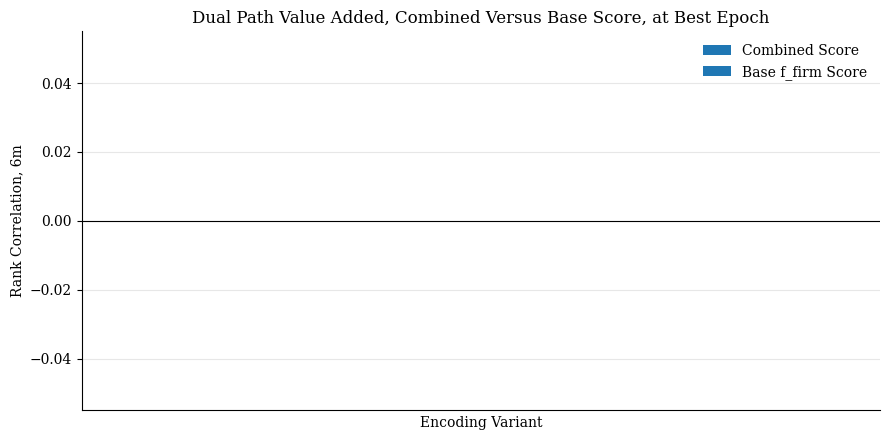

In [41]:
# dual path value added, combined score versus the base f_firm score alone,
# at each variant's best epoch
x_h = np.arange(len(dppt_variants_hpt))
width_h = 0.35
combined_vals = [dppt_best_params[v].get('best_corr_6m', float('nan')) for v in dppt_variants_hpt]
base_vals = [dppt_best_params[v].get('best_base_corr_6m', float('nan')) for v in dppt_variants_hpt]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x_h - width_h / 2, combined_vals, width_h, label='Combined Score', color='C0', alpha=0.85)
ax.bar(x_h + width_h / 2, base_vals, width_h, label='Base f_firm Score', color='C1', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_h)
ax.set_xticklabels(dppt_variants_hpt)
ax.set_xlabel('Encoding Variant')
ax.set_ylabel('Rank Correlation, 6m')
ax.set_title('Dual Path Value Added, Combined Versus Base Score, at Best Epoch')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_hpt_plots_dir / 'dppt_combined_vs_base_corr.pdf')
fig.savefig(dppt_hpt_plots_dir / 'dppt_combined_vs_base_corr.png')
plt.show()
plt.close(fig)

/var/folders/ng/4mdk7q7d2hschz1nhvq8_vmm0000gn/T/ipykernel_45724/2740393900.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False, fontsize=8)
/var/folders/ng/4mdk7q7d2hschz1nhvq8_vmm0000gn/T/ipykernel_45724/2740393900.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False, fontsize=8)


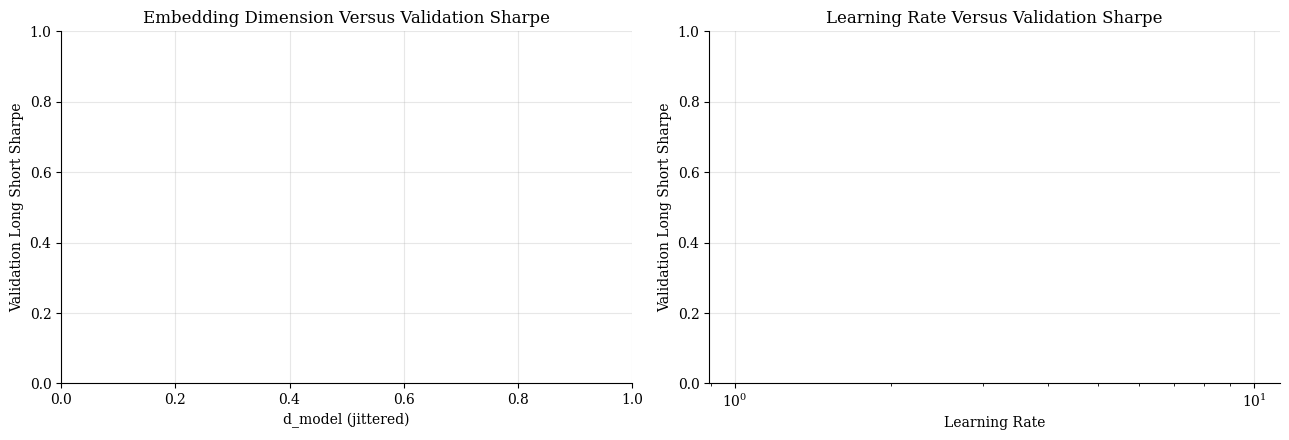

In [42]:
# embedding dimension and learning rate against the optuna objective,
# coloured by encoding variant, across every sampled trial
np.random.seed(7)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for variant in dppt_variants_hpt:
    sub = dppt_all_trials[dppt_all_trials['variant'] == variant]
    sub = sub[sub['value'].notna()]
    if len(sub) == 0:
        continue
    color = dppt_color_map[variant]
    jitter = (np.random.rand(len(sub)) - 0.5) * 4
    axes[0].scatter(sub['params_d_model'].to_numpy() + jitter, sub['value'].to_numpy(), s=18, alpha=0.6, color=color, label=variant)
    axes[1].scatter(sub['params_lr'].to_numpy(), sub['value'].to_numpy(), s=18, alpha=0.6, color=color, label=variant)

axes[0].set_xlabel('d_model (jittered)')
axes[0].set_ylabel('Validation Long Short Sharpe')
axes[0].set_title('Embedding Dimension Versus Validation Sharpe')
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Validation Long Short Sharpe')
axes[1].set_title('Learning Rate Versus Validation Sharpe')
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_hpt_plots_dir / 'dppt_hyperparameter_scatter.pdf')
fig.savefig(dppt_hpt_plots_dir / 'dppt_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

### Portfolio Evaluation

In [43]:
import re as re_dppt

dppt_metrics = {}
seed_pattern_dppt = re_dppt.compile(r'^metrics_(?P<variant>.+)_seed\d+\.json$')
for metrics_path in sorted(dppt_eval_dir.glob('metrics_*.json')):
    if seed_pattern_dppt.match(metrics_path.name):
        continue
    variant = metrics_path.stem[len('metrics_'):]
    with open(metrics_path) as fh:
        dppt_metrics[variant] = json.load(fh)

dppt_variants_eval = [v for v in dppt_variant_order if v in dppt_metrics]

comparison_rows = []
monthly_rows = []
for variant in dppt_variants_eval:
    m = dppt_metrics[variant]
    pm = m['portfolio_metrics']
    comparison_rows.append({
        'variant': variant,
        'val_corr': round(m['ensemble_val_rank_corr_6m'], 4),
        'val_sharpe_ls': round(m['validation_portfolio_metrics']['long_short']['sharpe_ratio'], 4),
        'test_corr_6m': round(m['ensemble_test_rank_corr_6m'], 4),
        'sharpe_lo': round(pm['long_only']['sharpe_ratio'], 4),
        'sharpe_lo_u': round(pm['long_only_unscaled']['sharpe_ratio'], 4),
        'sharpe_ls': round(pm['long_short']['sharpe_ratio'], 4),
        'sharpe_ls_u': round(pm['long_short_unscaled']['sharpe_ratio'], 4),
        'vol_ls': round(pm['long_short']['annualised_vol'], 4),
        'vol_ls_u': round(pm['long_short_unscaled']['annualised_vol'], 4),
    })
    monthly_rows.append({
        'variant': variant,
        'sharpe_lo_monthly': round(pm['long_only_monthly']['sharpe_ratio'], 4),
        'sharpe_lo_monthly_u': round(pm['long_only_monthly_unscaled']['sharpe_ratio'], 4),
        'sharpe_ls_monthly': round(pm['long_short_monthly']['sharpe_ratio'], 4),
        'sharpe_ls_monthly_u': round(pm['long_short_monthly_unscaled']['sharpe_ratio'], 4),
    })

dppt_comparison = pd.DataFrame(comparison_rows)
dppt_monthly_comparison = pd.DataFrame(monthly_rows)

dppt_best_variant = max(dppt_variants_eval, key=lambda v: dppt_metrics[v]['ensemble_val_rank_corr_6m'])
dppt_best_sharpe_variant = max(
    dppt_variants_eval,
    key=lambda v: dppt_metrics[v]['validation_portfolio_metrics']['long_short']['sharpe_ratio'],
)

print('dual path portfolio transformer, variant comparison')
print('test set columns are reported, validation set columns are the selection criteria')
print(dppt_comparison.to_string(index=False))
print()
print('monthly frequency sharpe ratios, 6m rebalance, target_1m monthly returns')
print(dppt_monthly_comparison.to_string(index=False))
print()
print(f'best variant by validation rank correlation, {dppt_best_variant}')
print(f'best variant by validation long short sharpe, {dppt_best_sharpe_variant}')

ValueError: max() iterable argument is empty

In [ ]:
x_e = np.arange(len(dppt_variants_eval))
width_e = 0.35
ls_vals = dppt_comparison['sharpe_ls'].to_numpy()
ls_monthly_vals = dppt_monthly_comparison['sharpe_ls_monthly'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x_e - width_e / 2, ls_vals, width_e, label='6m Rebalance Series', color='C0', alpha=0.85)
ax.bar(x_e + width_e / 2, ls_monthly_vals, width_e, label='Monthly Series', color='C1', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_e)
ax.set_xticklabels(dppt_variants_eval)
ax.set_xlabel('Encoding Variant')
ax.set_ylabel('Long Short Sharpe Ratio, Scaled')
ax.set_title('DPPT Test Set Long Short Sharpe Ratio by Variant')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / 'dppt_test_sharpe_by_variant.pdf')
fig.savefig(dppt_eval_plots_dir / 'dppt_test_sharpe_by_variant.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

In [ ]:
val_corrs = dppt_comparison['val_corr'].to_numpy()
test_corrs = dppt_comparison['test_corr_6m'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x_e - width_e / 2, val_corrs, width_e, label='Validation Set', color='C2', alpha=0.85)
ax.bar(x_e + width_e / 2, test_corrs, width_e, label='Test Set', color='C3', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_e)
ax.set_xticklabels(dppt_variants_eval)
ax.set_xlabel('Encoding Variant')
ax.set_ylabel('Rank Correlation, 6m')
ax.set_title('Validation Versus Test Rank Correlation by Variant')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / 'dppt_val_vs_test_corr.pdf')
fig.savefig(dppt_eval_plots_dir / 'dppt_val_vs_test_corr.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_per_month = pd.read_csv(dppt_eval_dir / f'per_month_{dppt_best_variant}.csv')
dppt_per_month['eom'] = pd.to_datetime(dppt_per_month['eom'])

dppt_strategy_order = [
    'long_only', 'long_short',
    'country_composite_long_only', 'country_composite_long_short',
]
dppt_strategy_labels = {
    'long_only': 'Long Only',
    'long_short': 'Long Short',
    'country_composite_long_only': 'Country Composite, Long Only',
    'country_composite_long_short': 'Country Composite, Long Short',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for k, strategy in enumerate(dppt_strategy_order):
    sub = dppt_per_month[
        (dppt_per_month['strategy'] == strategy) &
        (dppt_per_month['scaling'] == 'scaled')
    ].sort_values('eom')
    if len(sub) == 0:
        continue
    ax.plot(sub['eom'].to_numpy(), sub['cumulative_wealth'].to_numpy(), color=f'C{k}', label=dppt_strategy_labels[strategy])
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title(f'DPPT ({dppt_best_variant}), Monthly Cumulative Wealth by Strategy')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for variant in dppt_variants_eval:
    pm_path = dppt_eval_dir / f'per_month_{variant}.csv'
    if not pm_path.exists():
        continue
    pm_v = pd.read_csv(pm_path)
    sub_v = pm_v[(pm_v['strategy'] == 'long_short') & (pm_v['scaling'] == 'scaled')].sort_values('eom')
    if len(sub_v) == 0:
        continue
    ax.plot(pd.to_datetime(sub_v['eom']).to_numpy(), sub_v['cumulative_wealth'].to_numpy(), color=dppt_color_map[variant], label=variant)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('DPPT, Long Short Monthly Cumulative Wealth by Variant')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_cumulative_wealth_monthly.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_cumulative_wealth_monthly.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_ls_mo = dppt_per_month[
    (dppt_per_month['strategy'] == 'long_short') &
    (dppt_per_month['scaling'] == 'scaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.fill_between(dppt_ls_mo['eom'].to_numpy(), dppt_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color='C0')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title(f'DPPT ({dppt_best_variant}), Long Short Drawdown, Volatility Targeted')
ax.grid(alpha=0.3)

ax = axes[1]
valid_s = dppt_ls_mo['rolling_sharpe_12m'].notna()
ax.plot(dppt_ls_mo.loc[valid_s, 'eom'].to_numpy(), dppt_ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color='C0')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title(f'DPPT ({dppt_best_variant}), Rolling 12-Month Sharpe, Volatility Targeted')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_rolling_summary.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_rolling_summary.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_per_year = pd.read_csv(dppt_eval_dir / f'per_year_{dppt_best_variant}.csv')

dppt_py = dppt_per_year[
    (dppt_per_year['strategy'].isin(['long_short_monthly', 'long_only_monthly'])) &
    (dppt_per_year['scaling'] == 'scaled')
]

years_dppt = sorted(dppt_py['year'].unique())
x_dppt = np.arange(len(years_dppt))
width_dppt = 0.35


def _dppt_val(strategy, year, col):
    sub = dppt_py[(dppt_py['strategy'] == strategy) & (dppt_py['year'] == year)]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


ls_yr = [_dppt_val('long_short_monthly', y, 'ann_ret') for y in years_dppt]
lo_yr = [_dppt_val('long_only_monthly', y, 'ann_ret') for y in years_dppt]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_dppt - width_dppt / 2, ls_yr, width_dppt, label='Long Short', color='C0', alpha=0.8)
ax.bar(x_dppt + width_dppt / 2, lo_yr, width_dppt, label='Long Only', color='C1', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_dppt)
ax.set_xticklabels([str(y) for y in years_dppt])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title(f'DPPT ({dppt_best_variant}), Annualised Return by Year, Monthly Series, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_per_year_bar.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_per_year_bar.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_leverage = pd.read_parquet(dppt_eval_dir / f'leverage_{dppt_best_variant}.parquet')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for portfolio, color in [('long_only', 'C0'), ('country_composite_long_only', 'C1')]:
    sub = dppt_leverage[dppt_leverage['portfolio'] == portfolio].sort_values('rebalance_index')
    if len(sub) == 0:
        continue
    ax.step(sub['rebalance_index'].to_numpy(), sub['leverage'].to_numpy(), where='post', color=color, label=portfolio.replace('_', ' '))
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Rebalance Index')
ax.set_ylabel('Leverage')
ax.set_title(f'DPPT ({dppt_best_variant}), Long Only Leverage')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for portfolio, color in [('long_short', 'C2'), ('country_composite_long_short', 'C3')]:
    sub = dppt_leverage[dppt_leverage['portfolio'] == portfolio].sort_values('rebalance_index')
    if len(sub) == 0:
        continue
    ax.step(sub['rebalance_index'].to_numpy(), sub['leverage'].to_numpy(), where='post', color=color, label=portfolio.replace('_', ' '))
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Rebalance Index')
ax.set_ylabel('Leverage')
ax.set_title(f'DPPT ({dppt_best_variant}), Long Short Leverage')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_leverage.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_leverage.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_per_country_ls = dppt_metrics[dppt_best_variant]['per_country']['country_composite_long_short']

country_rows = []
for country_code, entry in dppt_per_country_ls.items():
    country_rows.append({
        'country': country_code,
        'sharpe_ratio': entry['sharpe_ratio'],
        'cumulative_contribution': entry['cumulative_contribution'] * 100,
        'annualised_vol': entry['annualised_vol'],
    })
dppt_country_df = pd.DataFrame(country_rows).sort_values('sharpe_ratio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.barh(range(len(dppt_country_df)), dppt_country_df['sharpe_ratio'].to_numpy()[::-1], color='C0')
ax.set_yticks(range(len(dppt_country_df)))
ax.set_yticklabels(dppt_country_df['country'].to_numpy()[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Sharpe Ratio')
ax.set_title(f'DPPT ({dppt_best_variant}), Country Composite Long Short, Sharpe by Country')
ax.grid(axis='x', alpha=0.3)

dppt_country_df_c = dppt_country_df.sort_values('cumulative_contribution', ascending=False)
ax = axes[1]
ax.barh(range(len(dppt_country_df_c)), dppt_country_df_c['cumulative_contribution'].to_numpy()[::-1], color='C1')
ax.set_yticks(range(len(dppt_country_df_c)))
ax.set_yticklabels(dppt_country_df_c['country'].to_numpy()[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cumulative Contribution (%)')
ax.set_title(f'DPPT ({dppt_best_variant}), Country Composite Long Short, Cumulative Contribution by Country')
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_per_country.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_per_country.png')
plt.show()
plt.close(fig)

In [ ]:
dppt_holdings = pd.read_parquet(dppt_eval_dir / f'holdings_{dppt_best_variant}.parquet')
dppt_holdings_ls = dppt_holdings[dppt_holdings['portfolio'] == 'long_short']

leg_counts = dppt_holdings_ls.groupby(['rebalance_index', 'leg']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
if 'long' in leg_counts.columns:
    ax.plot(leg_counts.index.to_numpy(), leg_counts['long'].to_numpy(), color='C0', label='Long Leg', marker='o', markersize=3)
if 'short' in leg_counts.columns:
    ax.plot(leg_counts.index.to_numpy(), leg_counts['short'].to_numpy(), color='C1', label='Short Leg', marker='o', markersize=3)
ax.set_xlabel('Rebalance Index')
ax.set_ylabel('Number of Positions')
ax.set_title(f'DPPT ({dppt_best_variant}), Long Short Leg Sizes Over Time')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
long_weights = dppt_holdings_ls.loc[dppt_holdings_ls['leg'] == 'long', 'weight'].to_numpy()
short_weights = dppt_holdings_ls.loc[dppt_holdings_ls['leg'] == 'short', 'weight'].abs().to_numpy()
ax.hist(long_weights, bins=40, alpha=0.6, color='C0', label='Long Leg')
ax.hist(short_weights, bins=40, alpha=0.6, color='C1', label='Short Leg')
ax.axvline(0.05, color='black', linewidth=0.8, linestyle='--', label='Position Cap')
ax.set_xlabel('Position Weight')
ax.set_ylabel('Frequency')
ax.set_title(f'DPPT ({dppt_best_variant}), Position Weight Distribution')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_holdings_summary.pdf')
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_variant}_holdings_summary.png')
plt.show()
plt.close(fig)